In [249]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import pandas as pd
import dunestyle.matplotlib as dunestyle
from tamaker import TAMaker
from presets import COLLECTION_CENTRAL_3VIEW, COLLECTION_LATERAL_3VIEW


# Load  data

In [250]:
def load_data(file_path, file_key, print_keys = False):
    with uproot.open(file_path) as file:

        #Print out keys, just to see what's there 
        if print_keys:
            for key in file.keys():
                print(key)

        tree = file[file_key]
        
        # Convert  TTree to pandas df
        df = tree.arrays( library="pd")


        return df 


# triggerAna/event_summary : gives total number of events, total visible energy in the full detector for the event (used for trigger efficiency plots)
# triggerAna/mcneutrinos & triggerAna/mctruths: contains mctruth information about the generator (GENIE in this case). (Unfortunately, because some people felt strongly about the 
# analyser dumping a single collection to a single TTree, it means we have to combine neutrino information from two TTrees to get the full picture )
# triggerAna/mcparticles : contains geant4 output 
# triggerAna/simides : contains simIDE information--> millions per event, and as this is already summarised in event_summary & TP bt_* fields, it's better not to use it unless necessary, as it can crash your kernel. 
# triggerAna/TriggerPrimitives : TPG output  

#filepath = './data/prodgenie_nu_dune10kt_1x2x6__trg_mc_2025a_tpg__tpg_dune10kt_1x2x6__triggerAna__v10_12_01d01__triggerana_dune10kt_1x2x6__v10_12_01d01__ntuple__NU_prod-pass2_v2_20251126T000804_f7.root'
filepath = './data/prodgenie_nue_dune10kt_1x2x6__trg_mc_2025a_tpg__tpg_dune10kt_1x2x6__triggerAna__v10_12_01d01__triggerana_dune10kt_1x2x6__v10_12_01d01__ntuple__NUE_prod-pass2_v2_20251203T003930_f7.root'

mctruth = load_data(filepath, 'triggerAna/mctruths', print_keys=True)
mcnu = load_data(filepath, 'triggerAna/mcneutrinos')
evsum =  load_data(filepath, 'triggerAna/event_summary')
tps =  load_data(filepath, 'triggerAna/TriggerPrimitives/tpmakerTPCsimpleThr__TPGen') 

ide =  pd.read_parquet("./data/genie_nue_roi_summary.parquet")
ide = ide[(ide.event.isin(evsum.event.unique())) & (ide.run.isin(evsum.run.unique()))]
ide.event.nunique()

triggerAna;1
triggerAna/TriggerPrimitives;1
triggerAna/TriggerPrimitives/tpmakerTPCsimpleThr__TPGen;1
triggerAna/TriggerPrimitives/tpmakerTPCabsRS__TPGen;1
triggerAna/simides;1
triggerAna/mcparticles;1
triggerAna/info;4
triggerAna/info;3
triggerAna/info;2
triggerAna/info;1
triggerAna/mctruths;1
triggerAna/mcneutrinos;1
triggerAna/event_summary;1


3988

### mctruth & mcnu df

In [251]:
#mcneutrino TTree is only useful because it contains detailed information about the interaction 
display(mcnu) #should be strictly one entry per event. 

#useful columns: ccnc; tells you if this was a neutral or charged current interaction, mode tells you the interaction type (see below)
ccnc_map = {'cc': 0, 'nc':1}; mode_map = {'QE': 0, 'RES': 1, 'DIS': 2, 'Coh. Prod': 3, '?': 5, 'MEC' : 10}

,event,run,subrun,block_id,generator_name,nupdg,leptonpdg,ccnc,mode,interactionType,target,hitnuc,hitquark,w,x,y,qsqr,pt,theta
0,73291,8528,0,0,,12,11,0,2,1091,1000180400,2112,1,2.052369,0.372137,0.919554,1.974089,0.309753,1.875585
1,73292,8528,0,0,generator,12,11,0,2,1091,1000180400,2212,1,2.474983,0.086526,0.851459,0.496722,0.362024,0.514993
2,73293,8528,0,0,generator,12,11,0,0,1001,1000180400,2112,0,0.842667,1.171020,0.192879,1.174176,0.279144,0.439204
3,73294,8528,0,0,generator,12,11,0,1,1000,1000180400,2112,0,1.931709,0.302146,0.660079,1.233919,0.332193,0.586657
4,73295,8528,0,0,generator,12,12,1,2,1092,1000180400,2112,1,5.333239,0.262678,0.926009,9.819155,2.167406,0.542511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,91266,8528,0,0,generator,12,11,0,2,1091,1000180400,2112,1,2.290577,0.361161,0.899292,2.467808,0.407990,1.316430
3996,91267,8528,0,0,generator,12,11,0,0,1001,1000180400,2112,0,1.206174,0.609669,0.465058,0.895433,0.169570,0.789643
3997,91268,8528,0,0,generator,12,11,0,1,1000,1000180400,2112,0,1.656441,0.031952,0.121789,0.061465,0.848068,0.031453
3998,91269,8528,0,0,generator,12,12,1,0,1002,1000180400,2112,0,0.951001,0.917894,0.060452,0.255266,0.247017,0.213173


In [252]:
display(mctruth)
#primary neutrino has truth_track_id == 0 
#useful columns : energy (in GeV); x,y,z give interaction vertex; pdg gives neutrino flavour; px,py,pz &p can be used to calculate neutrino direction w.r.t APA plane

,event,run,subrun,block_id,truth_track_id,pdg,generator_name,status_code,x,y,z,px,py,pz,p,energy,kinetic_energy,process
0,73291,8528,0,0,0,12,generator,0,-158.384604,58.441930,1037.149135,-0.000006,0.309753,3.056397,3.072053,3.072053,3.072053,primary
1,73291,8528,0,0,1,1000180400,generator,0,-158.384604,58.441930,1037.149135,0.000000,0.000000,0.000000,0.000000,37.215526,0.000000,primary
2,73291,8528,0,0,2,2112,generator,11,-158.384604,58.441930,1037.149135,-0.008889,0.001520,0.011238,NaN,0.925701,-0.013864,primary
3,73291,8528,0,0,3,1000180390,generator,2,-158.384604,58.441930,1037.149135,0.011086,-0.003995,-0.009889,0.174885,36.286251,0.000421,primary
4,73291,8528,0,0,4,22,generator,1,-158.384604,58.441930,1037.149135,-0.002197,0.002475,-0.001349,0.003574,0.003574,0.003574,primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67915,91270,8528,0,0,7,211,generator,14,-158.055560,338.400224,1340.258332,-0.080392,0.035754,-0.069234,0.111958,0.178926,0.039356,primary
67916,91270,8528,0,0,8,2212,generator,1,-158.055560,338.400224,1340.258332,0.229164,-0.184986,0.565429,0.637531,1.134372,0.196100,primary
67917,91270,8528,0,0,9,111,generator,1,-158.055560,338.400224,1340.258332,-0.034578,0.043829,-0.093796,0.109153,0.173589,0.038612,primary
67918,91270,8528,0,0,10,2212,generator,1,-158.055560,338.400224,1340.258332,-0.122222,0.042445,0.098086,0.162360,0.952216,0.013944,primary


In [253]:

#let's just extract the useful columns from mcnu TTree and combine both into a single df to make life easier. 
nu = pd.merge(mctruth[mctruth.truth_track_id == 0], mcnu[['event', 'run', 'subrun', 'ccnc', 'mode']], on=["event", "run", "subrun"])

display(nu) #now this should contain all the information about your neutrino: direction, vertex, energy, interaction type etc. 

,event,run,subrun,block_id,truth_track_id,pdg,generator_name,status_code,x,y,z,px,py,pz,p,energy,kinetic_energy,process,ccnc,mode
0,73291,8528,0,0,0,12,generator,0,-158.384604,58.441930,1037.149135,-0.000006,0.309753,3.056397,3.072053,3.072053,3.072053,primary,0,2
1,73292,8528,0,0,0,12,generator,0,-134.680114,514.371090,1302.675255,-0.000005,0.362024,3.572098,3.590396,3.590396,3.590396,primary,0,2
2,73293,8528,0,0,0,12,generator,0,-98.618235,562.667070,140.633797,-0.000002,0.279144,2.754279,2.768389,2.768389,2.768389,primary,0,0
3,73294,8528,0,0,0,12,generator,0,108.202243,-175.723307,267.559645,0.000003,0.332193,3.277911,3.294701,3.294701,3.294701,primary,0,1
4,73295,8528,0,0,0,12,generator,0,27.907082,-541.669600,708.620100,0.000001,2.167406,21.387467,21.497009,21.497009,21.497009,primary,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,91266,8528,0,0,0,12,generator,0,146.345006,452.446624,99.262885,0.000004,0.407990,4.025618,4.046239,4.046239,4.046239,primary,0,2
3996,91267,8528,0,0,0,12,generator,0,270.008948,-141.849331,1085.248208,0.000004,0.169570,1.673231,1.681801,1.681801,1.681801,primary,0,0
3997,91268,8528,0,0,0,12,generator,0,-47.611149,-584.263695,244.010293,-0.000002,0.848068,8.368540,8.411401,8.411401,8.411401,primary,0,1
3998,91269,8528,0,0,0,12,generator,0,202.407113,556.281842,1027.676651,0.000004,0.247017,2.437301,2.449787,2.449787,2.449787,primary,1,0


### event_summary

In [254]:
#ROP 0,1 == U, V induction planes. ROP 3,4 == collection planes from side A and side B of the APA. 
#To get the total visible energy in the collection planes for the entire detector just add up the ROPs 

evsum['visible_energy'] = evsum.tot_visible_energy_rop3 + evsum.tot_visible_energy_rop2 #Note: here the visible energy in measured in MeV
display(evsum)
evsum = evsum[evsum.visible_energy > 0]

,event,run,subrun,tot_visible_energy_rop0,tot_visible_energy_rop1,tot_visible_energy_rop2,tot_visible_energy_rop3,tot_numelectrons_rop0,tot_numelectrons_rop1,tot_numelectrons_rop2,tot_numelectrons_rop3,visible_energy
0,73291,8528,0,2170.115358,2170.268022,2004.877448,165.370108,4.420475e+07,4.420525e+07,4.188219e+07,2.323175e+06,2170.247556
1,73292,8528,0,2370.263977,2370.292077,2347.602457,22.749892,5.254493e+07,5.254513e+07,5.238375e+07,1.624302e+05,2370.352349
2,73293,8528,0,2582.455474,2582.363005,2578.898021,3.564080,6.361917e+07,6.361878e+07,6.353378e+07,8.600426e+04,2582.462101
3,73294,8528,0,3146.757758,3146.795238,0.000000,3146.760518,7.586452e+07,7.586455e+07,0.000000e+00,7.586505e+07,3146.760518
4,73295,8528,0,17335.663296,17335.538975,328.249404,17007.426064,4.402765e+08,4.402765e+08,7.121547e+06,4.331556e+08,17335.675468
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,91266,8528,0,3651.709432,3651.712737,0.568412,3651.205505,8.465470e+07,8.465529e+07,7.470000e+03,8.464824e+07,3651.773917
3996,91267,8528,0,1506.910324,1506.875595,0.000000,1507.020464,3.090848e+07,3.090840e+07,0.000000e+00,3.090929e+07,1507.020464
3997,91268,8528,0,7958.242753,7958.340728,7890.668298,67.674700,2.104237e+08,2.104234e+08,2.093392e+08,1.085256e+06,7958.342998
3998,91269,8528,0,28.618416,28.699753,0.000000,28.658903,3.656768e+05,3.656565e+05,0.000000e+00,3.656688e+05,28.658903


## TPs and TAs 

In [255]:
#pre-select only collection TPs and apply some cuts from the get-go to speed things up. 
tps_raw = tps[(tps.readout_view==2) &(tps.samples_over_threshold>8)]

In [256]:
maker = TAMaker(**COLLECTION_CENTRAL_3VIEW)
tas_c, tps_c = maker.run(tps_raw)

DBSCAN inspect: 100%|██████████| 7891/7891 [00:03<00:00, 2352.68it/s]


In [257]:
#  lateral efficiencies 

makerl = TAMaker(**COLLECTION_LATERAL_3VIEW)
tas_l, tps_l = makerl.run(tps_raw)

DBSCAN inspect: 100%|██████████| 10717/10717 [00:03<00:00, 2993.69it/s]


In [258]:
#add visible energy column to the tas 
tas_l =  pd.merge(tas_l, evsum[['event','visible_energy']], on=["event"]) 
tas_c =  pd.merge(tas_c, evsum[['event','visible_energy']], on=["event"]) 

#Merge the trigger dfs with the rest of the neutrino interactions 
tas_l = pd.merge(tas_l, nu[['event','mode', 'ccnc','x','y','z']], on="event")
tas_c = pd.merge(tas_c, nu[['event','mode', 'ccnc','x','y','z']], on="event")

In [259]:
from rich.console import Console
from rich.table import Table

trigl =  tas_l
trigc =  tas_c

console = Console()

counts = nu['ccnc'].value_counts()

table = Table(show_header=True, width =50, title=r"beam neutrinos")
for name in counts.index:
    label = next(k for k, v in ccnc_map.items() if v == name)
    table.add_column(label, justify="center")

row = [f"{(count / counts.sum()) * 100:.2g} %" for count in counts.values]
table.add_row(*row)

console.print(table)


counts = nu['mode'].value_counts()

table = Table(show_header=True, width =100, title='beam neutrinos')
for name in counts.index:
    label = next(k for k, v in mode_map.items() if v == name)
    table.add_column(label, justify="center")
row = [ f"{(count / counts.sum()) * 100:.2g} %"  for count in counts.values]
table.add_row(*row)

console.print(table)


print("Percentage of events triggered 'out of the box' ")
for idx , type_label in enumerate(ccnc_map):    

    print(f"Triggered {type_label} events (lateral): " , (trigl[(trigl.ccnc==idx) & (trigl.flag==2)].event.nunique()/trigl[(trigl.ccnc==idx) ].event.nunique() * 100))
    print(f"Triggered {type_label} events (central): " , (trigc[(trigc.ccnc==idx) & (trigc.flag==2)].event.nunique()/trigc[(trigc.ccnc==idx) ].event.nunique() * 100) )

print("Total (L): ",  int(trigl[(trigl.flag==2)].event.nunique()/trigl.event.nunique() * 100), ', (C):',  int(trigc[(trigc.flag==2)].event.nunique()/trigc.event.nunique() * 100))

print("\n" + "Percentage of events triggered on in the active volume ")

trigl_ac = trigl[(trigl.x.abs() <360) & (trigl.y.abs() < 600) & (trigl.z>0) & (trigl.z < 1380) & (trigl.visible_energy> 0)]
trigc_ac = trigc[(trigc.x.abs() <360) & (trigc.y.abs() < 600) & (trigc.z>0) & (trigc.z < 1380) & (trigc.visible_energy> 0)]

for idx , type_label in enumerate(ccnc_map):    

    print(f"Triggered {type_label} events (lateral): " , (trigl_ac[(trigl_ac.ccnc==idx) & (trigl_ac.flag==2)].event.nunique()/trigl_ac[(trigl_ac.ccnc==idx) ].event.nunique() * 100))
    print(f"Triggered {type_label} events (central): " , (trigc_ac[(trigc_ac.ccnc==idx) & (trigc_ac.flag==2)].event.nunique()/trigc_ac[(trigc_ac.ccnc==idx) ].event.nunique() * 100) )

print("Total (L): ",  trigl_ac[(trigl_ac.flag==2)].event.nunique()/trigl_ac.event.nunique() * 100, ', (C):',  trigc_ac[(trigc_ac.flag==2)].event.nunique()/trigc_ac.event.nunique() * 100, 
        ", 10 kT", 0.5*(trigl_ac[(trigl_ac.flag==2)].event.nunique()/trigl_ac.event.nunique() +trigc_ac[(trigc_ac.flag==2)].event.nunique()/trigc_ac.event.nunique() ) * 100)


# Fraction of events which produced less that 100 MeV of visible energy in the active volume 
# trig_beam_nue_lat[ (trig_beam_nue_lat.visible_energy < 100) &(trig_beam_nue_lat.event.isin(fv_event) &(trig_beam_nue_lat.ccnc==1))].event.nunique()/trig_beam_nue_lat[(trig_beam_nue_lat.event.isin(fv_event)) ].event.nunique() *100

                  beam neutrinos                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃           cc           ┃          nc           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│          78 %          │         22 %          │
└────────────────────────┴───────────────────────┘

                                           beam neutrinos                                           
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃     DIS     ┃     RES     ┃     QE      ┃     MEC      ┃      Coh. Prod       ┃        ?         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│    45 %     │    30 %     │    22 %     │    2.5 %     │        0.1 %         │     0.025 %      │
└─────────────┴─────────────┴─────────────┴──────────────┴──────────────────────┴──────────────────┘

Percentage of events triggered 'out of the box' 
Triggered cc events (lateral):  99.44948186528497
Triggered cc events (central):  99.51424870466322
Triggered nc events (lateral):  97.2520908004779
Triggered nc events (central):  97.37156511350061
Total (L):  98 , (C): 99

Percentage of events triggered on in the active volume 
Triggered cc events (lateral):  100.0
Triggered cc events (central):  100.0
Triggered nc events (lateral):  98.16031537450722
Triggered nc events (central):  98.16031537450722
Total (L):  99.59977129788452 , (C): 99.59977129788452 , 10 kT 99.59977129788452


In [260]:
tas_c

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,ch_wmean,t_wmean,ch_wstd,t_wstd,visible_energy,mode,ccnc,x,y,z
0,36531,9,2,3000,2,1,4248852,359,-1,-1.0,...,24870.482956,3336.626090,63.791761,61.887231,1212.774897,0,0,-269.369349,573.900570,989.457273
1,36532,5,3,3000,2,4,942853,91,-1,-1.0,...,15272.763557,3732.874318,83.784611,226.237538,921.056906,1,0,343.518783,46.030703,674.763913
2,36532,5,3,4000,2,5,1120359,102,-1,-1.0,...,15314.942570,4202.131024,23.823450,68.785863,921.056906,1,0,343.518783,46.030703,674.763913
3,36532,7,3,4000,2,6,741689,141,-1,-1.0,...,20068.635802,4388.743395,39.031621,61.473434,921.056906,1,0,343.518783,46.030703,674.763913
4,36533,5,3,3000,2,9,282788,23,-1,-1.0,...,15194.431907,3881.068465,72.264459,152.348159,196.238387,10,1,318.652756,92.123193,622.815134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22220,94989,4,3,0,0,31524,15839,3,0,0.0,...,-1.000000,-1.000000,-1.000000,-1.000000,8289.347081,2,1,0.288715,191.754704,540.537555
22221,94989,6,3,1000,0,31531,15122,3,1,11915.0,...,17865.369366,1136.738733,0.482633,0.965266,8289.347081,2,1,0.288715,191.754704,540.537555
22222,94989,7,3,1000,0,31536,18456,3,0,0.0,...,-1.000000,-1.000000,-1.000000,-1.000000,8289.347081,2,1,0.288715,191.754704,540.537555
22223,94989,7,3,4000,0,31538,15945,3,1,12324.0,...,20284.579438,4131.420562,0.493649,0.493649,8289.347081,2,1,0.288715,191.754704,540.537555


# TCs 

In [336]:

#map the TPC ID to a logical ix, iy, iz grid with origin at TPC0. (Assuming physical ordering that corresponds to the 1x2x6 TPC map.)
TPC_ID_TO_VOXEL = { i: (i % 2, (i // 2) % 2, i // 4) for i in range(24)}

# Invert grid mapping if needed:
VOXEL_TO_TPC_ID = {v: k for k, v in TPC_ID_TO_VOXEL.items()}

def get_tpcid(apa_id, plane_id):
    return apa_id * 2 + (plane_id - 2)

from tqdm import tqdm

def merge_tas(df):


    adjacency_req = ( -1, 0, 1)


    df = df[df.flag==2].copy() #only accepted windows 
    df['tpc'] = get_tpcid(df.apa_id, df.rop)
    
    window_size = 1000
    df["voxel"] = df["tpc"].map(TPC_ID_TO_VOXEL)
    df["it"] = (df["window_start"] // window_size).astype(int)
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    df["TC_id"] = -1
    tc_offset = 0

    for event_uid, event_df in tqdm(df.groupby("event"), total=df["event"].nunique()):

        event_df = event_df.copy()

        #process tas in time slices, such that we're only looking at it = k and k - 1 
        voxel_dict = {}
        for _, row in event_df.iterrows():
            voxel_dict.setdefault((row.it, row.ix, row.iy, row.iz), []).append(row)

        # initialise each TA to be its own parent --> each TA is a valid, stand-alone TC
        parent = {ta_id: ta_id for ta_id in event_df["TA_id"]}
        
        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i
 

        
        def union(i, j):
            ri = find(i)
            rj = find(j)
            if ri != rj:
                parent[rj] = ri

        for _, row in event_df.iterrows(): #loop over TAs & extract the voxel of the TA
            i = row.TA_id
            ix = row.ix; iy = row.iy
            iz = row.iz; it = row.it
            
            for it2 in (it, it - 1, it-2, it-3, it-4, it-5): #list of TAs in the relevant time slice --> single drift 
                for dx in adjacency_req:
                    for dy in adjacency_req:
                        for dz in adjacency_req:
                            for other in voxel_dict.get((it2, ix+dx, iy+dy, iz+dz), []):
                                j = other.TA_id
                                if i == j:
                                    continue
                                union(i, j)

        roots = {ta_id: find(ta_id) for ta_id in event_df["TA_id"]}
        unique_roots = {r: i + tc_offset for i, r in enumerate(sorted(set(roots.values())))}
        event_df["TC_id"] = event_df["TA_id"].map(lambda ta: unique_roots[roots[ta]])
        df.loc[event_df.index, "TC_id"] = event_df["TC_id"]
        tc_offset += len(unique_roots)
        
    return df

tas_c = merge_tas(tas_c)

100%|██████████| 3888/3888 [00:04<00:00, 950.20it/s] 


In [337]:
counts = tas_c.groupby("event").TC_id.nunique()
split_events = counts[counts > 1].index
print(split_events)

Index([42815, 43089, 64395, 66495, 75198, 75223, 75481, 75488, 75803, 76145,
       76370, 76417, 76437, 76456, 76739, 77334, 77873, 78326, 78442, 78551,
       79153, 79412, 80377, 81878, 81879, 82299, 82677, 83140, 83932, 83933,
       84573, 84922, 85267, 85995, 86281, 86399, 86428, 86644, 86745, 86773,
       87113, 87359, 87400, 87793, 87850, 87993, 88744, 88748, 89100, 89264,
       89764, 89767, 90255, 90663, 90727, 90978, 90992, 91032, 92154, 92157,
       92321, 92791, 92812, 93669, 93827, 94175, 94563, 94792, 94814, 94989],
      dtype='int64', name='event')


,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
40,42815,2,3,1000,2,82,1723686,61,-1,-1.0,...,137.410906,10.428308,230.066524,5,"(1, 0, 1)",1,1,0,1,14
41,42815,2,3,2000,2,83,305589,39,-1,-1.0,...,137.410906,10.428308,230.066524,5,"(1, 0, 1)",2,1,0,1,14
42,42815,3,3,0,2,84,136429,18,-1,-1.0,...,137.410906,10.428308,230.066524,7,"(1, 1, 1)",0,1,1,1,14
43,42815,3,3,1000,2,85,6113793,545,-1,-1.0,...,137.410906,10.428308,230.066524,7,"(1, 1, 1)",1,1,1,1,14
44,42815,3,3,2000,2,86,541149,99,-1,-1.0,...,137.410906,10.428308,230.066524,7,"(1, 1, 1)",2,1,1,1,14
14351,42815,7,2,4000,2,88,23605,5,1,23605.0,...,137.410906,10.428308,230.066524,14,"(0, 1, 3)",4,0,1,3,15


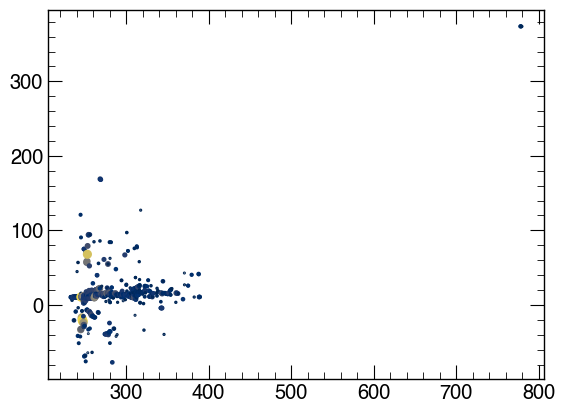

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
104,43089,1,3,2000,2,219,4472510,287,-1,-1.0,...,248.750841,473.434732,144.92371,3,"(1, 1, 0)",2,1,1,0,29
105,43089,1,3,3000,2,220,3011163,306,-1,-1.0,...,248.750841,473.434732,144.92371,3,"(1, 1, 0)",3,1,1,0,29
106,43089,3,3,1000,2,223,197177,19,-1,-1.0,...,248.750841,473.434732,144.92371,7,"(1, 1, 1)",1,1,1,1,29
107,43089,3,3,2000,2,224,1177823,112,-1,-1.0,...,248.750841,473.434732,144.92371,7,"(1, 1, 1)",2,1,1,1,29
108,43089,3,3,3000,2,225,1482867,164,-1,-1.0,...,248.750841,473.434732,144.92371,7,"(1, 1, 1)",3,1,1,1,29
109,43089,7,3,4000,2,229,150720,12,-1,-1.0,...,248.750841,473.434732,144.92371,15,"(1, 1, 3)",4,1,1,3,30


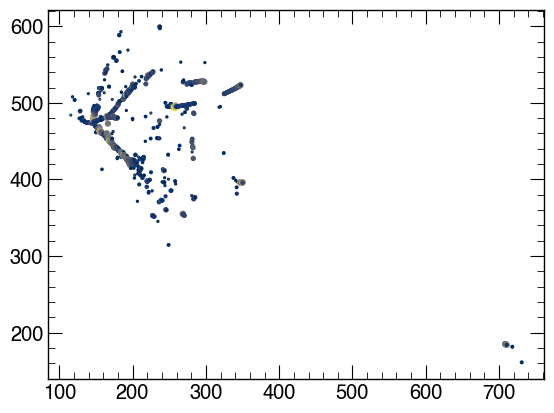

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
207,64395,0,2,0,2,435,444180,42,-1,-1.0,...,-47.478361,-37.466666,42.877243,0,"(0, 0, 0)",0,0,0,0,56
208,64395,4,3,0,2,441,205188,12,-1,-1.0,...,-47.478361,-37.466666,42.877243,9,"(1, 0, 2)",0,1,0,2,57
14437,64395,0,3,0,2,436,43690,5,1,30095.0,...,-47.478361,-37.466666,42.877243,1,"(1, 0, 0)",0,1,0,0,56


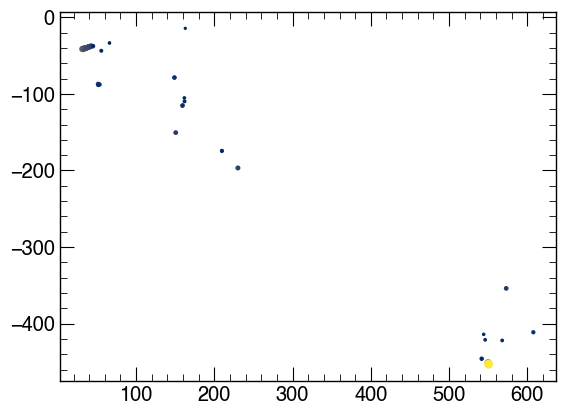

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
239,66495,0,3,2000,2,504,563774,47,-1,-1.0,...,200.5884,-143.622357,85.581915,1,"(1, 0, 0)",2,1,0,0,66
14455,66495,6,3,0,2,509,21035,4,2,10517.5,...,200.5884,-143.622357,85.581915,13,"(1, 0, 3)",0,1,0,3,67


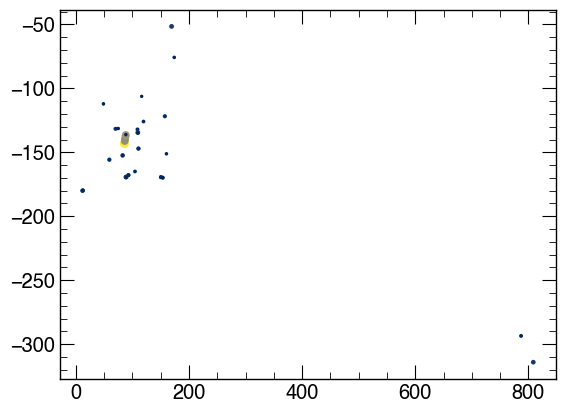

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
1547,75198,4,3,2000,2,3267,91772,30,-1,-1.0,...,299.189839,-213.368343,590.380802,9,"(1, 0, 2)",2,1,0,2,414
1548,75198,4,3,3000,2,3268,33548221,958,-1,-1.0,...,299.189839,-213.368343,590.380802,9,"(1, 0, 2)",3,1,0,2,414
1549,75198,4,3,4000,2,3269,736710,92,-1,-1.0,...,299.189839,-213.368343,590.380802,9,"(1, 0, 2)",4,1,0,2,414
1550,75198,6,3,3000,2,3272,17644706,1014,-1,-1.0,...,299.189839,-213.368343,590.380802,13,"(1, 0, 3)",3,1,0,3,414
1551,75198,6,3,4000,2,3273,1051068,166,-1,-1.0,...,299.189839,-213.368343,590.380802,13,"(1, 0, 3)",4,1,0,3,414
15107,75198,6,3,1000,2,3270,48699,10,4,9644.0,...,299.189839,-213.368343,590.380802,13,"(1, 0, 3)",1,1,0,3,414
15108,75198,6,3,2000,2,3271,26086,7,2,8928.5,...,299.189839,-213.368343,590.380802,13,"(1, 0, 3)",2,1,0,3,414
15109,75198,10,2,4000,2,3275,18339,4,1,17143.0,...,299.189839,-213.368343,590.380802,20,"(0, 0, 5)",4,0,0,5,415


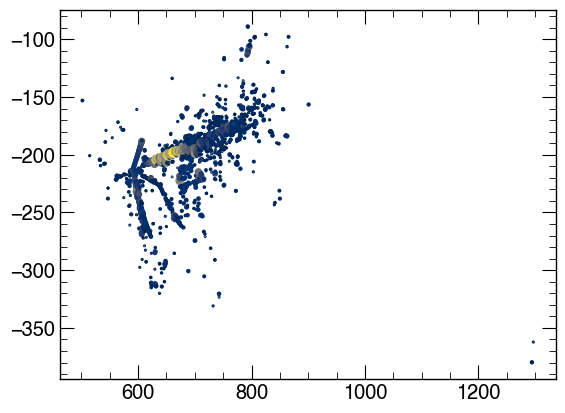

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
1562,75223,1,3,1000,2,3297,508574,39,-1,-1.0,...,143.559939,557.618506,28.648575,3,"(1, 1, 0)",1,1,1,0,420
1563,75223,1,3,2000,2,3298,94470,3,-1,-1.0,...,143.559939,557.618506,28.648575,3,"(1, 1, 0)",2,1,1,0,420
15116,75223,7,2,4000,2,3299,24704,6,1,23446.0,...,143.559939,557.618506,28.648575,14,"(0, 1, 3)",4,0,1,3,421


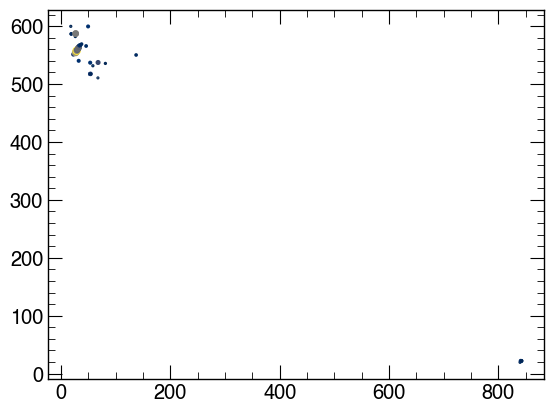

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
1770,75481,4,2,3000,2,3732,201585,27,-1,-1.0,...,-379.113079,-437.243442,662.792177,8,"(0, 0, 2)",3,0,0,2,479
1771,75481,4,2,4000,2,3733,388317,50,-1,-1.0,...,-379.113079,-437.243442,662.792177,8,"(0, 0, 2)",4,0,0,2,479
1772,75481,6,2,4000,2,3735,310972,37,-1,-1.0,...,-379.113079,-437.243442,662.792177,12,"(0, 0, 3)",4,0,0,3,479
1773,75481,10,2,4000,2,3737,239637,29,-1,-1.0,...,-379.113079,-437.243442,662.792177,20,"(0, 0, 5)",4,0,0,5,480


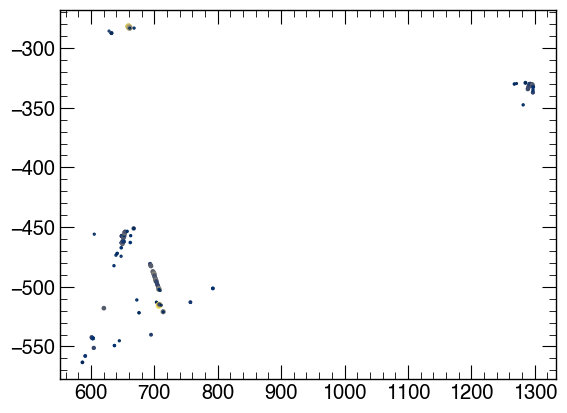

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
1791,75488,2,3,2000,2,3773,545288,56,-1,-1.00,...,299.24542,-96.801167,350.698118,5,"(1, 0, 1)",2,1,0,1,487
1792,75488,2,3,3000,2,3774,10409225,830,-1,-1.00,...,299.24542,-96.801167,350.698118,5,"(1, 0, 1)",3,1,0,1,487
1793,75488,4,3,2000,2,3779,72731,19,-1,-1.00,...,299.24542,-96.801167,350.698118,9,"(1, 0, 2)",2,1,0,2,487
1794,75488,4,3,3000,2,3780,1533785,166,-1,-1.00,...,299.24542,-96.801167,350.698118,9,"(1, 0, 2)",3,1,0,2,487
15215,75488,2,3,4000,2,3775,37948,11,4,8216.75,...,299.24542,-96.801167,350.698118,5,"(1, 0, 1)",4,1,0,1,487
15216,75488,3,3,3000,2,3776,26976,7,2,13488.00,...,299.24542,-96.801167,350.698118,7,"(1, 1, 1)",3,1,1,1,487
15218,75488,9,2,4000,2,3785,15167,3,1,15167.00,...,299.24542,-96.801167,350.698118,18,"(0, 1, 4)",4,0,1,4,488


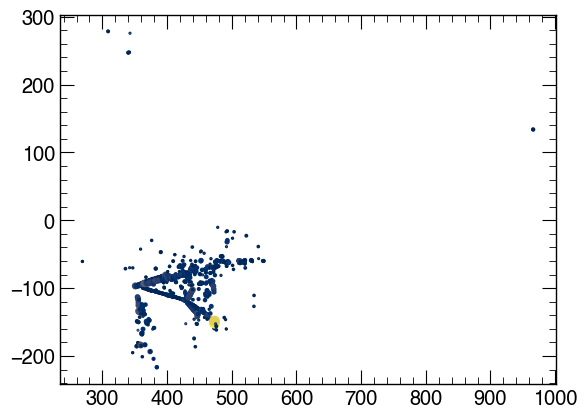

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2044,75803,0,2,0,2,4340,3762922,307,-1,-1.0,...,-24.976943,-398.392609,102.716902,0,"(0, 0, 0)",0,0,0,0,558
2045,75803,2,2,0,2,4343,144951,14,-1,-1.0,...,-24.976943,-398.392609,102.716902,4,"(0, 0, 1)",0,0,0,1,558
2046,75803,6,3,2000,2,4348,442289,24,-1,-1.0,...,-24.976943,-398.392609,102.716902,13,"(1, 0, 3)",2,1,0,3,559


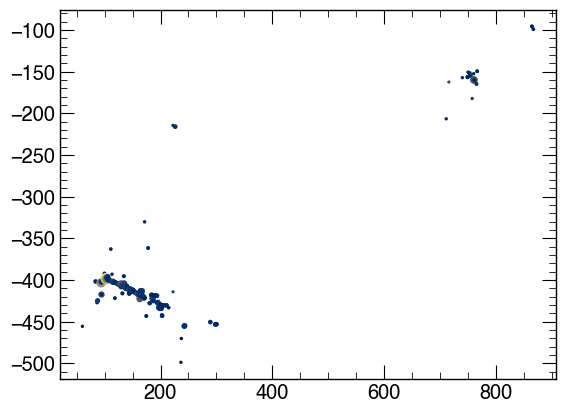

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2284,76145,1,2,1000,2,4868,196303,31,-1,-1.0,...,-244.103576,298.056712,2.975431,2,"(0, 1, 0)",1,0,1,0,621
2285,76145,1,2,2000,2,4869,2596659,235,-1,-1.0,...,-244.103576,298.056712,2.975431,2,"(0, 1, 0)",2,0,1,0,621
2286,76145,1,2,3000,2,4870,2177550,266,-1,-1.0,...,-244.103576,298.056712,2.975431,2,"(0, 1, 0)",3,0,1,0,621
2287,76145,3,2,3000,2,4871,400388,36,-1,-1.0,...,-244.103576,298.056712,2.975431,6,"(0, 1, 1)",3,0,1,1,621
15491,76145,3,3,1000,2,4872,17674,3,1,15442.0,...,-244.103576,298.056712,2.975431,7,"(1, 1, 1)",1,1,1,1,621
15492,76145,7,2,0,2,4873,21452,3,1,17132.0,...,-244.103576,298.056712,2.975431,14,"(0, 1, 3)",0,0,1,3,622


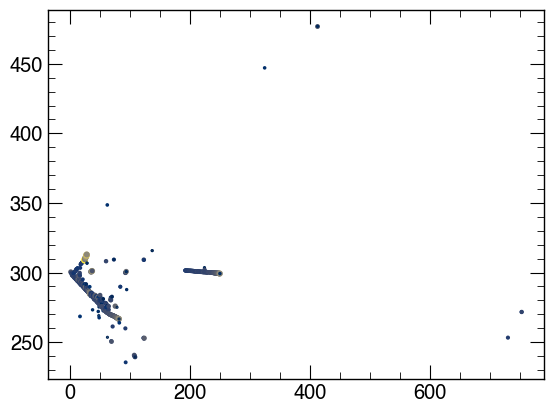

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2505,76370,6,2,0,2,5362,2565523,309,-1,-1.0,...,-16.338715,-300.948727,734.471161,12,"(0, 0, 3)",0,0,0,3,687
2506,76370,6,2,1000,2,5363,688832,41,-1,-1.0,...,-16.338715,-300.948727,734.471161,12,"(0, 0, 3)",1,0,0,3,687
15620,76370,3,3,2000,2,5360,15411,2,1,15411.0,...,-16.338715,-300.948727,734.471161,7,"(1, 1, 1)",2,1,1,1,686
15621,76370,6,3,0,2,5364,42258,9,4,10564.5,...,-16.338715,-300.948727,734.471161,13,"(1, 0, 3)",0,1,0,3,687


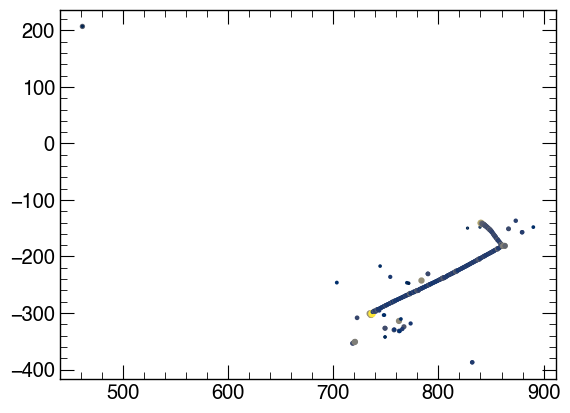

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2526,76417,0,2,2000,2,5406,1170111,114,-1,-1.0,...,-231.065718,-285.820103,107.571562,0,"(0, 0, 0)",2,0,0,0,694
2527,76417,0,2,3000,2,5407,1236000,172,-1,-1.0,...,-231.065718,-285.820103,107.571562,0,"(0, 0, 0)",3,0,0,0,694
15635,76417,5,3,1000,2,5410,20290,3,1,15525.0,...,-231.065718,-285.820103,107.571562,11,"(1, 1, 2)",1,1,1,2,695


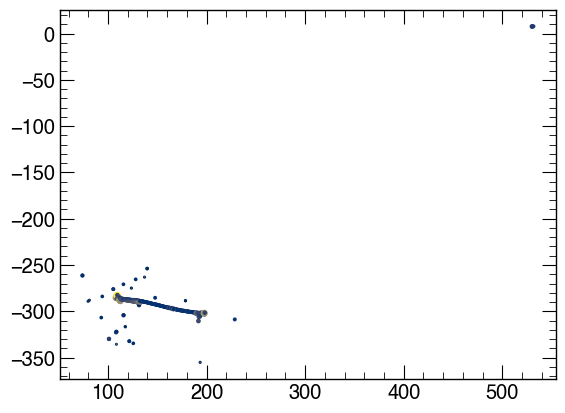

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2555,76437,3,2,2000,2,5466,237520,18,-1,-1.0,...,-364.714273,204.695995,247.227572,6,"(0, 1, 1)",2,0,1,1,705
2556,76437,3,2,3000,2,5467,181838,59,-1,-1.0,...,-364.714273,204.695995,247.227572,6,"(0, 1, 1)",3,0,1,1,705
2557,76437,3,2,4000,2,5468,32857064,1295,-1,-1.0,...,-364.714273,204.695995,247.227572,6,"(0, 1, 1)",4,0,1,1,705
2558,76437,5,2,4000,2,5470,734802,134,-1,-1.0,...,-364.714273,204.695995,247.227572,10,"(0, 1, 2)",4,0,1,2,705
15653,76437,11,2,4000,2,5471,48937,6,1,48937.0,...,-364.714273,204.695995,247.227572,22,"(0, 1, 5)",4,0,1,5,706


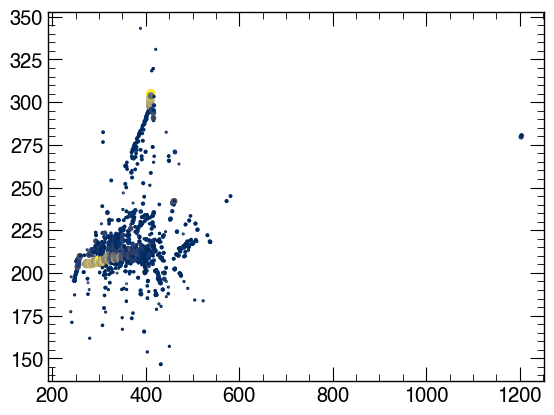

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2588,76456,1,2,2000,2,5533,817451,123,-1,-1.0,...,-263.774648,125.121825,40.315338,2,"(0, 1, 0)",2,0,1,0,715
2589,76456,1,2,3000,2,5534,7108942,594,-1,-1.0,...,-263.774648,125.121825,40.315338,2,"(0, 1, 0)",3,0,1,0,715
2590,76456,5,2,3000,2,5539,1173031,109,-1,-1.0,...,-263.774648,125.121825,40.315338,10,"(0, 1, 2)",3,0,1,2,716
15675,76456,5,2,4000,2,5540,29190,8,2,12344.5,...,-263.774648,125.121825,40.315338,10,"(0, 1, 2)",4,0,1,2,716


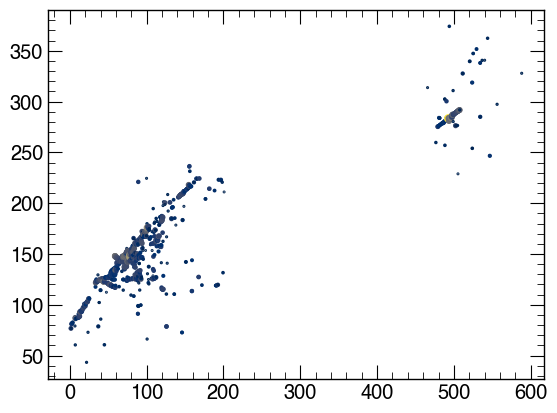

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
2783,76739,9,2,0,2,5953,39753431,1207,-1,-1.0,...,-15.519401,164.587777,1027.724602,18,"(0, 1, 4)",0,0,1,4,769
2784,76739,9,2,1000,2,5954,232318,22,-1,-1.0,...,-15.519401,164.587777,1027.724602,18,"(0, 1, 4)",1,0,1,4,769
2785,76739,9,3,0,2,5957,4430198,353,-1,-1.0,...,-15.519401,164.587777,1027.724602,19,"(1, 1, 4)",0,1,1,4,769
2786,76739,11,2,0,2,5960,7900070,680,-1,-1.0,...,-15.519401,164.587777,1027.724602,22,"(0, 1, 5)",0,0,1,5,769
2787,76739,11,3,0,2,5962,1992567,170,-1,-1.0,...,-15.519401,164.587777,1027.724602,23,"(1, 1, 5)",0,1,1,5,769
15767,76739,5,2,0,2,5949,20534,4,1,15841.0,...,-15.519401,164.587777,1027.724602,10,"(0, 1, 2)",0,0,1,2,768
15770,76739,8,3,0,2,5952,20587,4,1,15568.0,...,-15.519401,164.587777,1027.724602,17,"(1, 0, 4)",0,1,0,4,769


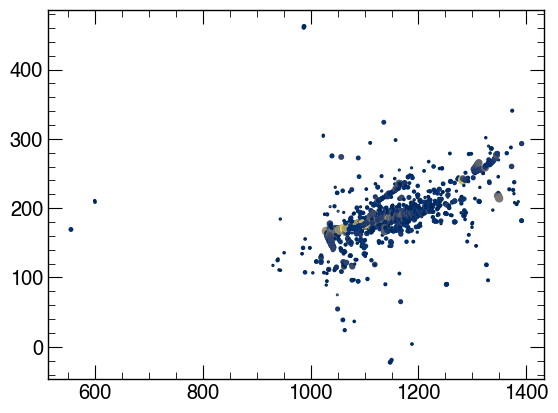

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
3189,77334,6,2,1000,2,6829,342044,28,-1,-1.0,...,-158.093277,-3.878446,856.80969,12,"(0, 0, 3)",1,0,0,3,871
3190,77334,6,2,2000,2,6830,673272,68,-1,-1.0,...,-158.093277,-3.878446,856.80969,12,"(0, 0, 3)",2,0,0,3,871
3191,77334,10,2,4000,2,6834,123172,5,-1,-1.0,...,-158.093277,-3.878446,856.80969,20,"(0, 0, 5)",4,0,0,5,872


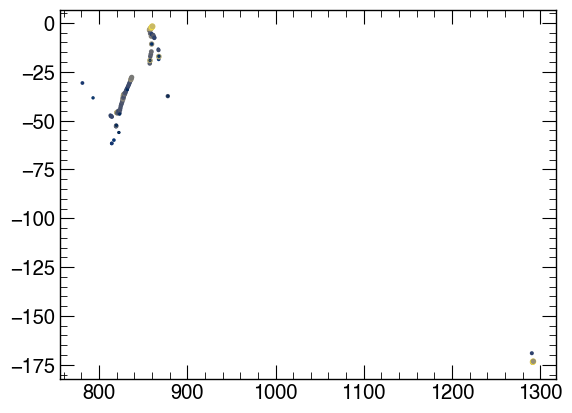

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
3596,77873,5,3,1000,2,7746,69042,21,-1,-1.0,...,171.430564,201.240478,581.916386,11,"(1, 1, 2)",1,1,1,2,989
3597,77873,5,3,2000,2,7747,10792471,557,-1,-1.0,...,171.430564,201.240478,581.916386,11,"(1, 1, 2)",2,1,1,2,989
3598,77873,7,3,1000,2,7749,143841,27,-1,-1.0,...,171.430564,201.240478,581.916386,15,"(1, 1, 3)",1,1,1,3,989
3599,77873,7,3,2000,2,7750,2790868,352,-1,-1.0,...,171.430564,201.240478,581.916386,15,"(1, 1, 3)",2,1,1,3,989
16233,77873,11,3,0,2,7751,21297,5,1,15407.0,...,171.430564,201.240478,581.916386,23,"(1, 1, 5)",0,1,1,5,990


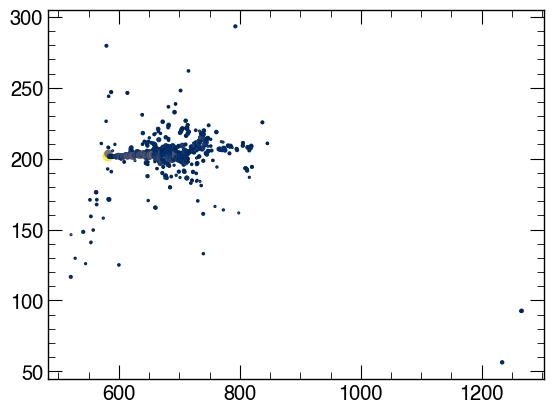

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
3956,78326,0,2,1000,2,8555,149806,34,-1,-1.0,...,-194.155991,-21.16759,-19.172,0,"(0, 0, 0)",1,0,0,0,1091
3957,78326,0,2,2000,2,8556,311030,64,-1,-1.0,...,-194.155991,-21.16759,-19.172,0,"(0, 0, 0)",2,0,0,0,1091
3958,78326,1,2,2000,2,8560,215612,35,-1,-1.0,...,-194.155991,-21.16759,-19.172,2,"(0, 1, 0)",2,0,1,0,1091
16424,78326,0,2,3000,2,8557,37121,8,2,15563.0,...,-194.155991,-21.16759,-19.172,0,"(0, 0, 0)",3,0,0,0,1091
16428,78326,4,2,1000,2,8567,21137,3,1,15406.0,...,-194.155991,-21.16759,-19.172,8,"(0, 0, 2)",1,0,0,2,1092


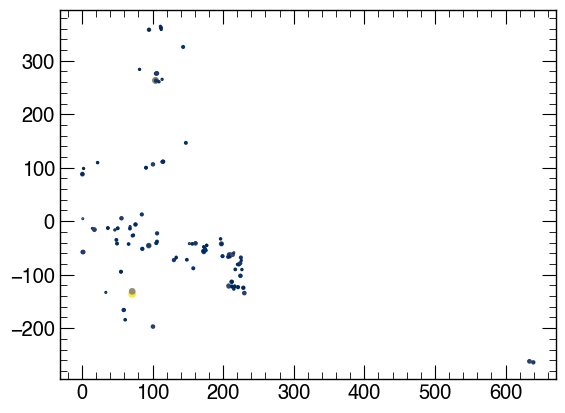

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
4014,78442,4,3,2000,2,8691,4353394,283,-1,-1.0,...,230.853904,-265.330253,545.125127,9,"(1, 0, 2)",2,1,0,2,1107
4015,78442,4,3,3000,2,8692,1355645,121,-1,-1.0,...,230.853904,-265.330253,545.125127,9,"(1, 0, 2)",3,1,0,2,1107
4016,78442,6,3,0,2,8694,110136,8,-1,-1.0,...,230.853904,-265.330253,545.125127,13,"(1, 0, 3)",0,1,0,3,1107
4017,78442,11,2,2000,2,8697,88196,29,-1,-1.0,...,230.853904,-265.330253,545.125127,22,"(0, 1, 5)",2,0,1,5,1108
16459,78442,11,2,3000,2,8698,30171,8,2,11158.0,...,230.853904,-265.330253,545.125127,22,"(0, 1, 5)",3,0,1,5,1108


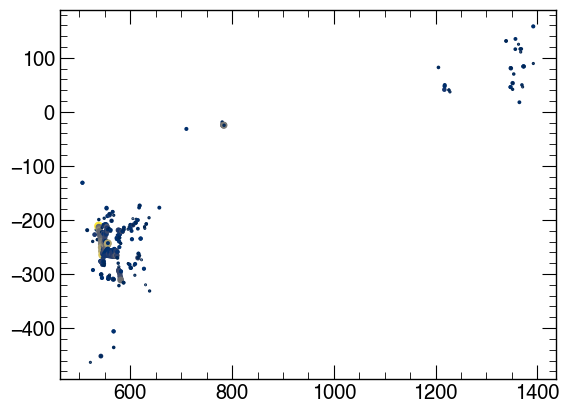

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
4119,78551,1,2,3000,2,8939,10479022,743,-1,-1.0,...,-325.186454,580.883018,119.217903,2,"(0, 1, 0)",3,0,1,0,1136
4120,78551,1,2,4000,2,8940,4147174,509,-1,-1.0,...,-325.186454,580.883018,119.217903,2,"(0, 1, 0)",4,0,1,0,1136
4121,78551,3,2,3000,2,8942,804874,144,-1,-1.0,...,-325.186454,580.883018,119.217903,6,"(0, 1, 1)",3,0,1,1,1136
4122,78551,3,2,4000,2,8943,1135849,154,-1,-1.0,...,-325.186454,580.883018,119.217903,6,"(0, 1, 1)",4,0,1,1,1136
4123,78551,5,2,3000,2,8944,88260,18,-1,-1.0,...,-325.186454,580.883018,119.217903,10,"(0, 1, 2)",3,0,1,2,1136
4124,78551,5,2,4000,2,8945,176799,30,-1,-1.0,...,-325.186454,580.883018,119.217903,10,"(0, 1, 2)",4,0,1,2,1136
4125,78551,11,2,4000,2,8948,369950,36,-1,-1.0,...,-325.186454,580.883018,119.217903,22,"(0, 1, 5)",4,0,1,5,1137
16523,78551,3,2,2000,2,8941,41170,12,4,8575.5,...,-325.186454,580.883018,119.217903,6,"(0, 1, 1)",2,0,1,1,1136
16524,78551,11,2,3000,2,8947,30716,6,1,29393.0,...,-325.186454,580.883018,119.217903,22,"(0, 1, 5)",3,0,1,5,1137


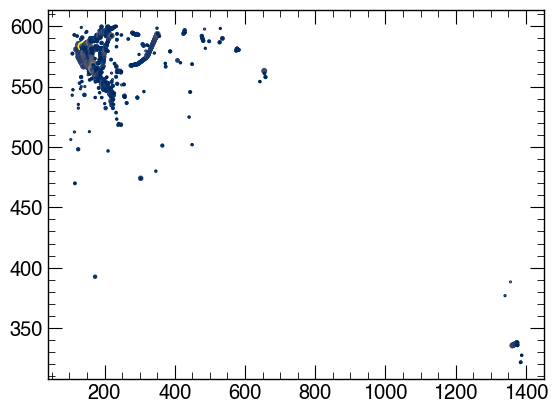

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
4492,79153,5,2,1000,2,9779,705829,73,-1,-1.0,...,-190.83256,154.088489,522.077921,10,"(0, 1, 2)",1,0,1,2,1245
4493,79153,5,2,2000,2,9780,3817933,248,-1,-1.0,...,-190.83256,154.088489,522.077921,10,"(0, 1, 2)",2,0,1,2,1245
4494,79153,5,2,3000,2,9781,113189,20,-1,-1.0,...,-190.83256,154.088489,522.077921,10,"(0, 1, 2)",3,0,1,2,1245
4495,79153,9,2,2000,2,9784,129182,6,-1,-1.0,...,-190.83256,154.088489,522.077921,18,"(0, 1, 4)",2,0,1,4,1246
16728,79153,9,2,3000,2,9785,43590,4,2,21795.0,...,-190.83256,154.088489,522.077921,18,"(0, 1, 4)",3,0,1,4,1246


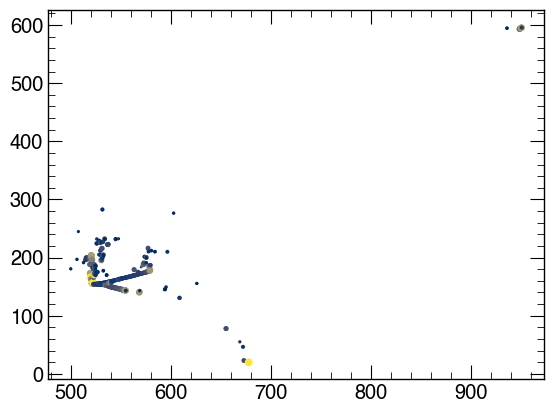

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
4604,79412,0,2,0,2,10025,4948178,573,-1,-1.0,...,-51.704342,-537.330489,131.909253,0,"(0, 0, 0)",0,0,0,0,1274
4605,79412,0,2,1000,2,10026,322881,27,-1,-1.0,...,-51.704342,-537.330489,131.909253,0,"(0, 0, 0)",1,0,0,0,1274
4606,79412,0,3,0,2,10029,75666,8,-1,-1.0,...,-51.704342,-537.330489,131.909253,1,"(1, 0, 0)",0,1,0,0,1274
4607,79412,2,2,0,2,10031,1573692,141,-1,-1.0,...,-51.704342,-537.330489,131.909253,4,"(0, 0, 1)",0,0,0,1,1274
4608,79412,2,3,0,2,10034,2327023,196,-1,-1.0,...,-51.704342,-537.330489,131.909253,5,"(1, 0, 1)",0,1,0,1,1274
16785,79412,0,2,3000,2,10028,54460,10,3,16257.0,...,-51.704342,-537.330489,131.909253,0,"(0, 0, 0)",3,0,0,0,1274
16786,79412,0,3,1000,2,10030,20165,3,1,15215.0,...,-51.704342,-537.330489,131.909253,1,"(1, 0, 0)",1,1,0,0,1274
16787,79412,2,2,1000,2,10032,25033,5,1,16555.0,...,-51.704342,-537.330489,131.909253,4,"(0, 0, 1)",1,0,0,1,1274
16790,79412,6,2,0,2,10037,23346,4,1,16291.0,...,-51.704342,-537.330489,131.909253,12,"(0, 0, 3)",0,0,0,3,1275


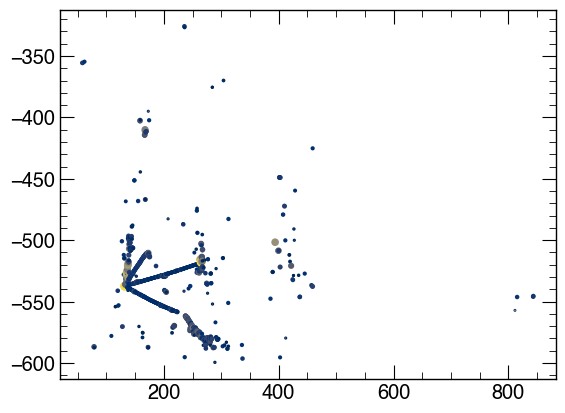

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
5143,80377,8,2,3000,2,11217,55006,12,-1,-1.0,...,-379.929276,-619.49292,1005.60001,16,"(0, 0, 4)",3,0,0,4,1413
17088,80377,4,2,4000,2,11216,17937,4,1,17937.0,...,-379.929276,-619.49292,1005.60001,8,"(0, 0, 2)",4,0,0,2,1412
17089,80377,8,2,4000,2,11218,25898,7,2,10622.5,...,-379.929276,-619.49292,1005.60001,16,"(0, 0, 4)",4,0,0,4,1413


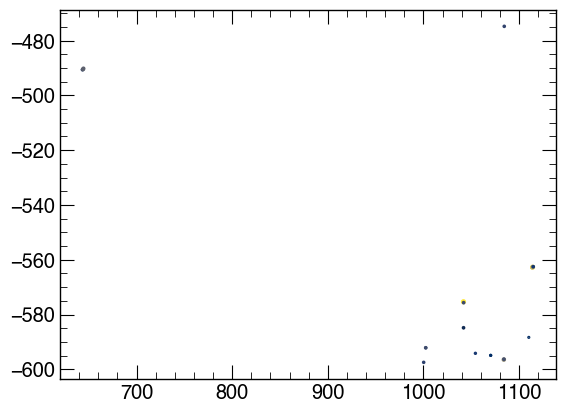

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
5879,81878,7,3,3000,2,12801,300845,32,-1,-1.0,...,339.958408,225.970705,924.704763,15,"(1, 1, 3)",3,1,1,3,1633
5880,81878,7,3,4000,2,12802,421203,27,-1,-1.0,...,339.958408,225.970705,924.704763,15,"(1, 1, 3)",4,1,1,3,1633
5881,81878,9,3,2000,2,12806,176486,30,-1,-1.0,...,339.958408,225.970705,924.704763,19,"(1, 1, 4)",2,1,1,4,1633
5882,81878,9,3,3000,2,12807,1559505,215,-1,-1.0,...,339.958408,225.970705,924.704763,19,"(1, 1, 4)",3,1,1,4,1633
5883,81878,9,3,4000,2,12808,14107709,1200,-1,-1.0,...,339.958408,225.970705,924.704763,19,"(1, 1, 4)",4,1,1,4,1633
5884,81878,11,3,4000,2,12812,83866,18,-1,-1.0,...,339.958408,225.970705,924.704763,23,"(1, 1, 5)",4,1,1,5,1633
17500,81878,1,2,0,2,12797,21515,3,1,20131.0,...,339.958408,225.970705,924.704763,2,"(0, 1, 0)",0,0,1,0,1632
17502,81878,8,3,1000,2,12803,18722,4,1,15573.0,...,339.958408,225.970705,924.704763,17,"(1, 0, 4)",1,1,0,4,1633
17505,81878,11,3,2000,2,12811,26142,6,2,11568.5,...,339.958408,225.970705,924.704763,23,"(1, 1, 5)",2,1,1,5,1633


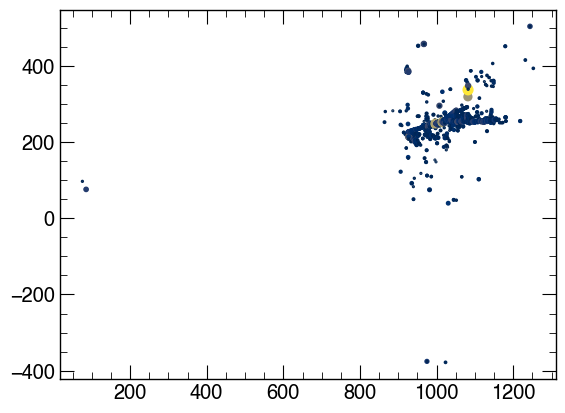

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
5885,81879,9,2,1000,2,12814,2507942,192,-1,-1.0,...,-113.665475,368.992303,1114.143862,18,"(0, 1, 4)",1,0,1,4,1635
5886,81879,9,2,2000,2,12815,333325,37,-1,-1.0,...,-113.665475,368.992303,1114.143862,18,"(0, 1, 4)",2,0,1,4,1635
5887,81879,11,2,1000,2,12817,97093,18,-1,-1.0,...,-113.665475,368.992303,1114.143862,22,"(0, 1, 5)",1,0,1,5,1635
5888,81879,11,2,2000,2,12818,302597,22,-1,-1.0,...,-113.665475,368.992303,1114.143862,22,"(0, 1, 5)",2,0,1,5,1635
17506,81879,5,2,0,2,12813,20030,5,1,15379.0,...,-113.665475,368.992303,1114.143862,10,"(0, 1, 2)",0,0,1,2,1634


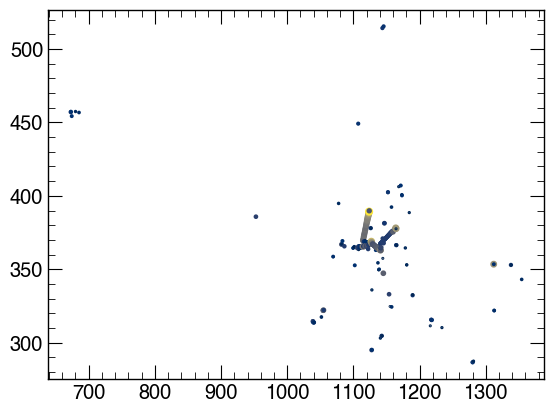

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
6004,82299,1,2,3000,2,13060,289849,39,-1,-1.0,...,-360.90545,435.792949,153.129991,2,"(0, 1, 0)",3,0,1,0,1664
6005,82299,1,2,4000,2,13061,2054998,244,-1,-1.0,...,-360.90545,435.792949,153.129991,2,"(0, 1, 0)",4,0,1,0,1664
6006,82299,3,2,3000,2,13063,333823,34,-1,-1.0,...,-360.90545,435.792949,153.129991,6,"(0, 1, 1)",3,0,1,1,1664
6007,82299,3,2,4000,2,13064,3135404,470,-1,-1.0,...,-360.90545,435.792949,153.129991,6,"(0, 1, 1)",4,0,1,1,1664
17570,82299,3,2,2000,2,13062,22033,3,1,20856.0,...,-360.90545,435.792949,153.129991,6,"(0, 1, 1)",2,0,1,1,1664
17571,82299,7,2,3000,2,13065,21602,5,2,10801.0,...,-360.90545,435.792949,153.129991,14,"(0, 1, 3)",3,0,1,3,1665


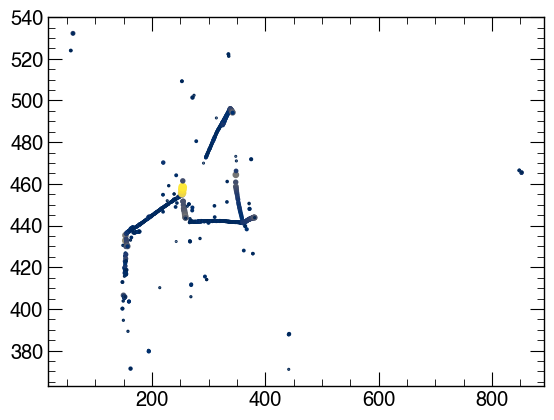

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
6255,82677,6,3,2000,2,13616,65216,19,-1,-1.0,...,283.567273,-206.907045,725.543457,13,"(1, 0, 3)",2,1,0,3,1741
6256,82677,6,3,3000,2,13617,4842244,494,-1,-1.0,...,283.567273,-206.907045,725.543457,13,"(1, 0, 3)",3,1,0,3,1741
6257,82677,6,3,4000,2,13618,854236,89,-1,-1.0,...,283.567273,-206.907045,725.543457,13,"(1, 0, 3)",4,1,0,3,1741
17711,82677,2,2,1000,2,13613,19741,3,1,15339.0,...,283.567273,-206.907045,725.543457,4,"(0, 0, 1)",1,0,0,1,1740


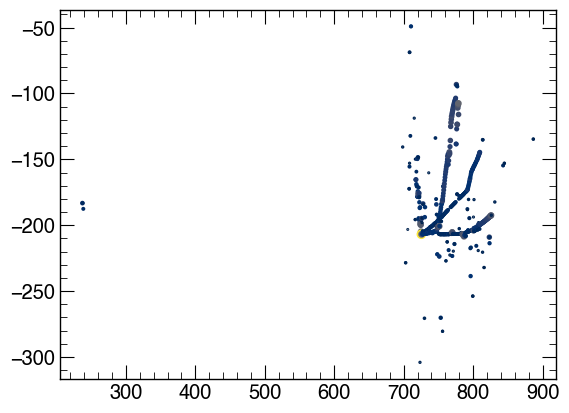

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
6640,83140,1,3,0,2,14479,5176987,234,-1,-1.000000,...,74.155323,378.033727,123.51113,3,"(1, 1, 0)",0,1,1,0,1841
6641,83140,1,3,1000,2,14480,1828100,139,-1,-1.000000,...,74.155323,378.033727,123.51113,3,"(1, 1, 0)",1,1,1,0,1841
17913,83140,5,2,1000,2,14485,50511,13,3,10502.333333,...,74.155323,378.033727,123.51113,10,"(0, 1, 2)",1,0,1,2,1842


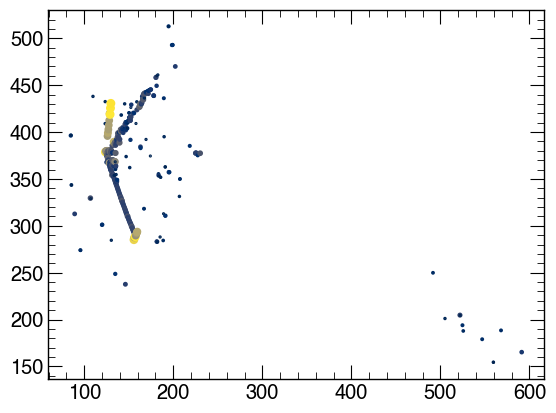

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
7039,83932,3,3,0,2,15382,3767968,341,-1,-1.0,...,147.705577,210.182807,276.238871,7,"(1, 1, 1)",0,1,1,1,1949
7040,83932,3,3,1000,2,15383,15988629,1406,-1,-1.0,...,147.705577,210.182807,276.238871,7,"(1, 1, 1)",1,1,1,1,1949
7041,83932,3,3,2000,2,15384,9121688,823,-1,-1.0,...,147.705577,210.182807,276.238871,7,"(1, 1, 1)",2,1,1,1,1949
7042,83932,3,3,3000,2,15385,167598,40,-1,-1.0,...,147.705577,210.182807,276.238871,7,"(1, 1, 1)",3,1,1,1,1949
7043,83932,5,3,0,2,15388,446858,50,-1,-1.0,...,147.705577,210.182807,276.238871,11,"(1, 1, 2)",0,1,1,2,1949
7044,83932,5,3,2000,2,15390,156406,40,-1,-1.0,...,147.705577,210.182807,276.238871,11,"(1, 1, 2)",2,1,1,2,1949
18129,83932,3,2,0,2,15381,23282,4,1,16135.0,...,147.705577,210.182807,276.238871,6,"(0, 1, 1)",0,0,1,1,1949
18131,83932,5,3,1000,2,15389,34707,6,2,14343.0,...,147.705577,210.182807,276.238871,11,"(1, 1, 2)",1,1,1,2,1949
18134,83932,11,3,3000,2,15396,20135,3,1,20135.0,...,147.705577,210.182807,276.238871,23,"(1, 1, 5)",3,1,1,5,1950


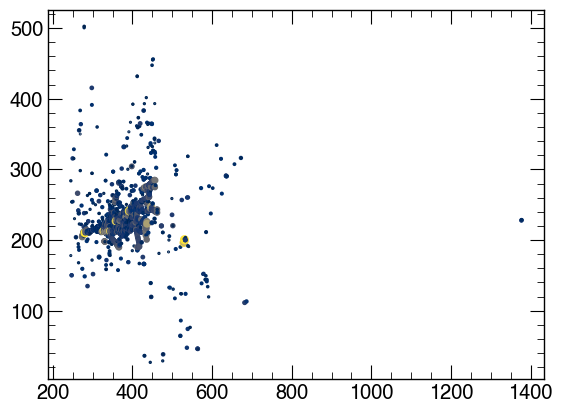

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
7045,83933,8,3,2000,2,15403,615848,84,-1,-1.0,...,265.608062,-93.453435,1004.436731,17,"(1, 0, 4)",2,1,0,4,1952
7046,83933,8,3,3000,2,15404,9557862,700,-1,-1.0,...,265.608062,-93.453435,1004.436731,17,"(1, 0, 4)",3,1,0,4,1952
7047,83933,8,3,4000,2,15405,153880,33,-1,-1.0,...,265.608062,-93.453435,1004.436731,17,"(1, 0, 4)",4,1,0,4,1952
7048,83933,9,3,3000,2,15407,58394,16,-1,-1.0,...,265.608062,-93.453435,1004.436731,19,"(1, 1, 4)",3,1,1,4,1952
7049,83933,10,3,0,2,15409,66159,10,-1,-1.0,...,265.608062,-93.453435,1004.436731,21,"(1, 0, 5)",0,1,0,5,1952
7050,83933,10,3,1000,2,15410,111083,20,-1,-1.0,...,265.608062,-93.453435,1004.436731,21,"(1, 0, 5)",1,1,0,5,1952
18135,83933,2,3,2000,2,15398,19384,3,1,15224.0,...,265.608062,-93.453435,1004.436731,5,"(1, 0, 1)",2,1,0,1,1951
18136,83933,6,2,0,2,15400,15190,2,1,15190.0,...,265.608062,-93.453435,1004.436731,12,"(0, 0, 3)",0,0,0,3,1952


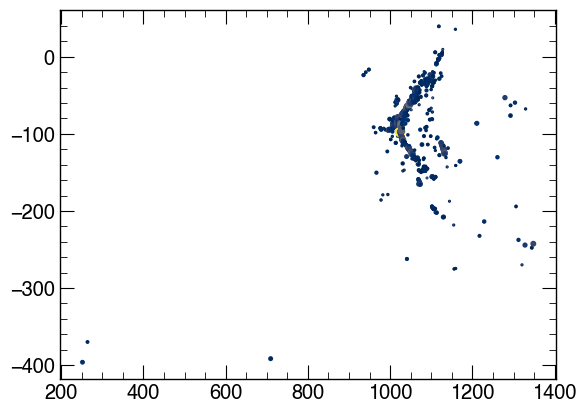

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
7360,84573,4,3,3000,2,16021,1215176,55,-1,-1.0,...,296.645579,-254.145033,683.211657,9,"(1, 0, 2)",3,1,0,2,2042
7361,84573,6,3,3000,2,16026,2198398,209,-1,-1.0,...,296.645579,-254.145033,683.211657,13,"(1, 0, 3)",3,1,0,3,2042
7362,84573,6,3,4000,2,16027,1477913,127,-1,-1.0,...,296.645579,-254.145033,683.211657,13,"(1, 0, 3)",4,1,0,3,2042
18267,84573,0,3,3000,2,16020,17949,3,1,17949.0,...,296.645579,-254.145033,683.211657,1,"(1, 0, 0)",3,1,0,0,2041


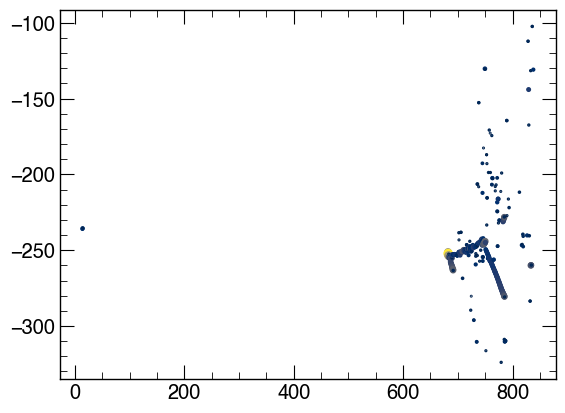

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
7620,84922,8,2,0,2,16621,1872855,205,-1,-1.000000,...,-75.18821,3.943654,1076.98133,16,"(0, 0, 4)",0,0,0,4,2109
7621,84922,8,2,1000,2,16622,1587125,113,-1,-1.000000,...,-75.18821,3.943654,1076.98133,16,"(0, 0, 4)",1,0,0,4,2109
7622,84922,9,2,0,2,16625,49699726,509,-1,-1.000000,...,-75.18821,3.943654,1076.98133,18,"(0, 1, 4)",0,0,1,4,2109
7623,84922,9,2,1000,2,16626,5209583,262,-1,-1.000000,...,-75.18821,3.943654,1076.98133,18,"(0, 1, 4)",1,0,1,4,2109
7624,84922,9,2,2000,2,16627,121766,24,-1,-1.000000,...,-75.18821,3.943654,1076.98133,18,"(0, 1, 4)",2,0,1,4,2109
7625,84922,10,2,0,2,16633,4981310,487,-1,-1.000000,...,-75.18821,3.943654,1076.98133,20,"(0, 0, 5)",0,0,0,5,2109
7626,84922,10,2,1000,2,16634,1858978,276,-1,-1.000000,...,-75.18821,3.943654,1076.98133,20,"(0, 0, 5)",1,0,0,5,2109
7627,84922,10,2,2000,2,16635,104881,21,-1,-1.000000,...,-75.18821,3.943654,1076.98133,20,"(0, 0, 5)",2,0,0,5,2109
7628,84922,10,3,0,2,16637,217857,32,-1,-1.000000,...,-75.18821,3.943654,1076.98133,21,"(1, 0, 5)",0,1,0,5,2109
7629,84922,11,2,0,2,16640,67102271,2499,-1,-1.000000,...,-75.18821,3.943654,1076.98133,22,"(0, 1, 5)",0,0,1,5,2109


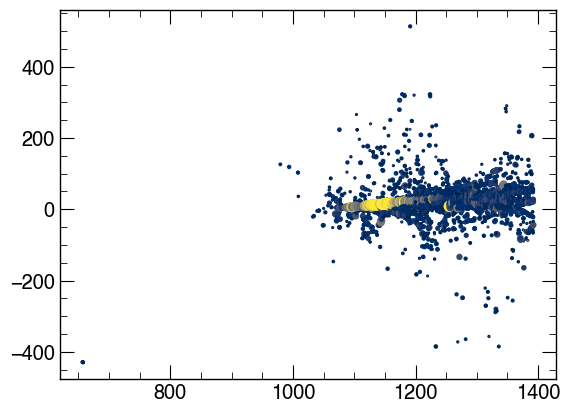

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
7832,85267,3,2,0,2,17077,21786389,629,-1,-1.000000,...,-22.626342,547.141419,392.77527,6,"(0, 1, 1)",0,0,1,1,2163
7833,85267,3,3,0,2,17079,374264,37,-1,-1.000000,...,-22.626342,547.141419,392.77527,7,"(1, 1, 1)",0,1,1,1,2163
7834,85267,5,2,0,2,17080,15525872,1003,-1,-1.000000,...,-22.626342,547.141419,392.77527,10,"(0, 1, 2)",0,0,1,2,2163
7835,85267,5,2,1000,2,17081,80545,18,-1,-1.000000,...,-22.626342,547.141419,392.77527,10,"(0, 1, 2)",1,0,1,2,2163
7836,85267,5,3,0,2,17083,8975248,850,-1,-1.000000,...,-22.626342,547.141419,392.77527,11,"(1, 1, 2)",0,1,1,2,2163
7837,85267,5,3,1000,2,17084,286369,32,-1,-1.000000,...,-22.626342,547.141419,392.77527,11,"(1, 1, 2)",1,1,1,2,2163
7838,85267,7,3,0,2,17086,242448,44,-1,-1.000000,...,-22.626342,547.141419,392.77527,15,"(1, 1, 3)",0,1,1,3,2163
18534,85267,3,2,1000,2,17078,21770,3,1,21770.000000,...,-22.626342,547.141419,392.77527,6,"(0, 1, 1)",1,0,1,1,2163
18535,85267,5,3,2000,2,17085,38678,8,3,11297.666667,...,-22.626342,547.141419,392.77527,11,"(1, 1, 2)",2,1,1,2,2163
18538,85267,11,3,0,2,17090,22727,3,1,20186.000000,...,-22.626342,547.141419,392.77527,23,"(1, 1, 5)",0,1,1,5,2164


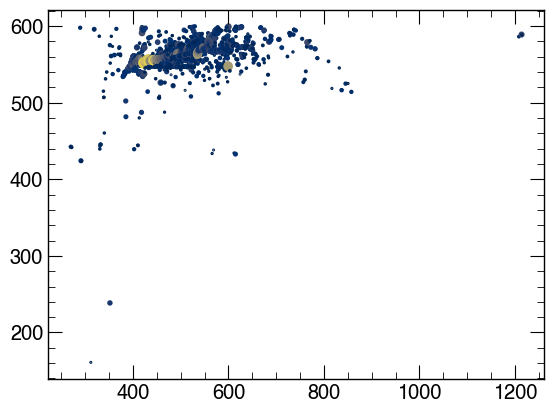

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8260,85995,5,3,0,2,18001,6765265,391,-1,-1.0,...,39.750362,275.113916,640.374424,11,"(1, 1, 2)",0,1,1,2,2278
8261,85995,5,3,1000,2,18002,380621,18,-1,-1.0,...,39.750362,275.113916,640.374424,11,"(1, 1, 2)",1,1,1,2,2278
8262,85995,7,3,0,2,18005,6779395,563,-1,-1.0,...,39.750362,275.113916,640.374424,15,"(1, 1, 3)",0,1,1,3,2278
8263,85995,7,3,1000,2,18006,121225,28,-1,-1.0,...,39.750362,275.113916,640.374424,15,"(1, 1, 3)",1,1,1,3,2278
18764,85995,5,2,1000,2,17999,31870,5,2,14744.5,...,39.750362,275.113916,640.374424,10,"(0, 1, 2)",1,0,1,2,2278
18766,85995,5,3,2000,2,18003,29974,3,1,29974.0,...,39.750362,275.113916,640.374424,11,"(1, 1, 2)",2,1,1,2,2278
18767,85995,7,2,0,2,18004,23124,4,2,11562.0,...,39.750362,275.113916,640.374424,14,"(0, 1, 3)",0,0,1,3,2278
18768,85995,10,3,0,2,18007,19481,4,1,17092.0,...,39.750362,275.113916,640.374424,21,"(1, 0, 5)",0,1,0,5,2279


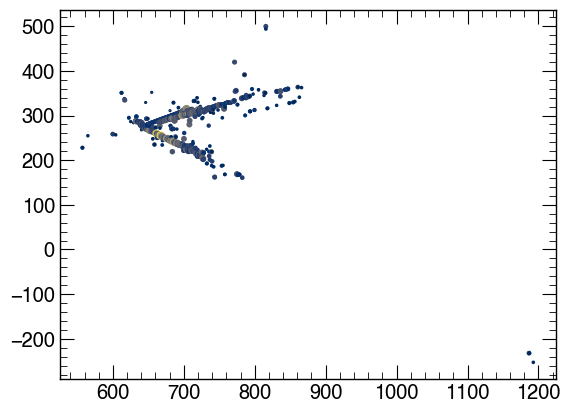

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8454,86281,5,2,4000,2,18449,6666781,278,-1,-1.0,...,-354.835525,605.406896,602.553973,10,"(0, 1, 2)",4,0,1,2,2335
8455,86281,7,2,3000,2,18451,128411,27,-1,-1.0,...,-354.835525,605.406896,602.553973,14,"(0, 1, 3)",3,0,1,3,2335
8456,86281,7,2,4000,2,18452,14237270,755,-1,-1.0,...,-354.835525,605.406896,602.553973,14,"(0, 1, 3)",4,0,1,3,2335
8457,86281,11,3,2000,2,18453,56556,13,-1,-1.0,...,-354.835525,605.406896,602.553973,23,"(1, 1, 5)",2,1,1,5,2336


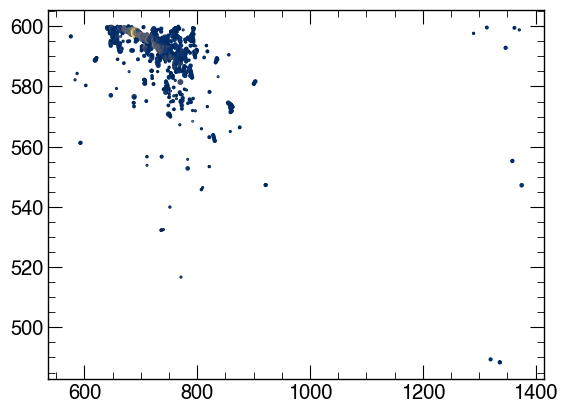

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8557,86399,7,3,1000,2,18646,1390797,162,-1,-1.0,...,128.973323,342.77166,728.279754,15,"(1, 1, 3)",1,1,1,3,2364
18927,86399,4,3,4000,2,18641,21970,4,1,21033.0,...,128.973323,342.77166,728.279754,9,"(1, 0, 2)",4,1,0,2,2364
18929,86399,7,3,0,2,18645,54911,11,2,18040.0,...,128.973323,342.77166,728.279754,15,"(1, 1, 3)",0,1,1,3,2364
18932,86399,11,2,1000,2,18654,15921,3,1,15921.0,...,128.973323,342.77166,728.279754,22,"(0, 1, 5)",1,0,1,5,2365


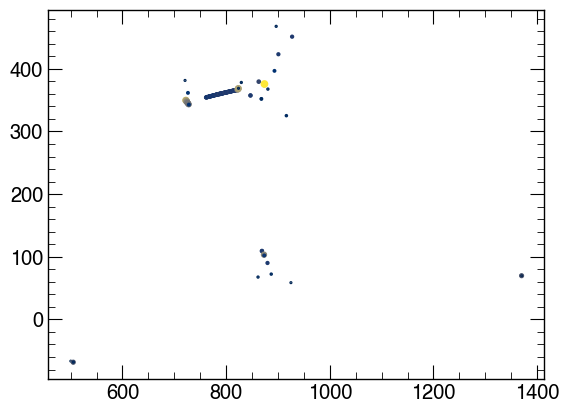

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8590,86428,0,3,2000,2,18728,62009,10,-1,-1.0,...,368.436704,-111.689657,236.671074,1,"(1, 0, 0)",2,1,0,0,2374
8591,86428,0,3,3000,2,18729,124788,30,-1,-1.0,...,368.436704,-111.689657,236.671074,1,"(1, 0, 0)",3,1,0,0,2374
8592,86428,2,3,3000,2,18736,1048936,151,-1,-1.0,...,368.436704,-111.689657,236.671074,5,"(1, 0, 1)",3,1,0,1,2374
8593,86428,2,3,4000,2,18737,14487767,1249,-1,-1.0,...,368.436704,-111.689657,236.671074,5,"(1, 0, 1)",4,1,0,1,2374
8594,86428,4,3,2000,2,18742,75481,24,-1,-1.0,...,368.436704,-111.689657,236.671074,9,"(1, 0, 2)",2,1,0,2,2374
8595,86428,4,3,3000,2,18743,5462529,514,-1,-1.0,...,368.436704,-111.689657,236.671074,9,"(1, 0, 2)",3,1,0,2,2374
8596,86428,4,3,4000,2,18744,13170370,1297,-1,-1.0,...,368.436704,-111.689657,236.671074,9,"(1, 0, 2)",4,1,0,2,2374
8597,86428,5,3,3000,2,18747,1028689,127,-1,-1.0,...,368.436704,-111.689657,236.671074,11,"(1, 1, 2)",3,1,1,2,2374
8598,86428,6,3,3000,2,18749,135912,23,-1,-1.0,...,368.436704,-111.689657,236.671074,13,"(1, 0, 3)",3,1,0,3,2374
8599,86428,6,3,4000,2,18750,1199280,265,-1,-1.0,...,368.436704,-111.689657,236.671074,13,"(1, 0, 3)",4,1,0,3,2374


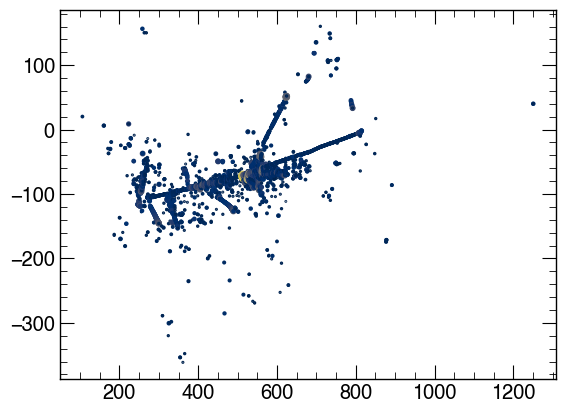

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8734,86644,5,2,0,2,19058,89096,24,-1,-1.0,...,-137.216482,364.705029,513.291319,10,"(0, 1, 2)",0,0,1,2,2410
8735,86644,5,2,1000,2,19059,53348657,2094,-1,-1.0,...,-137.216482,364.705029,513.291319,10,"(0, 1, 2)",1,0,1,2,2410
8736,86644,5,2,2000,2,19060,719477,84,-1,-1.0,...,-137.216482,364.705029,513.291319,10,"(0, 1, 2)",2,0,1,2,2410
8737,86644,7,2,1000,2,19066,1646477,247,-1,-1.0,...,-137.216482,364.705029,513.291319,14,"(0, 1, 3)",1,0,1,3,2410
8738,86644,7,2,2000,2,19067,211186,44,-1,-1.0,...,-137.216482,364.705029,513.291319,14,"(0, 1, 3)",2,0,1,3,2410
8739,86644,7,2,4000,2,19069,144600,13,-1,-1.0,...,-137.216482,364.705029,513.291319,14,"(0, 1, 3)",4,0,1,3,2410
19029,86644,1,3,1000,2,19053,15347,3,1,15347.0,...,-137.216482,364.705029,513.291319,3,"(1, 1, 0)",1,1,1,0,2409
19032,86644,7,2,0,2,19065,40974,4,1,29054.0,...,-137.216482,364.705029,513.291319,14,"(0, 1, 3)",0,0,1,3,2410


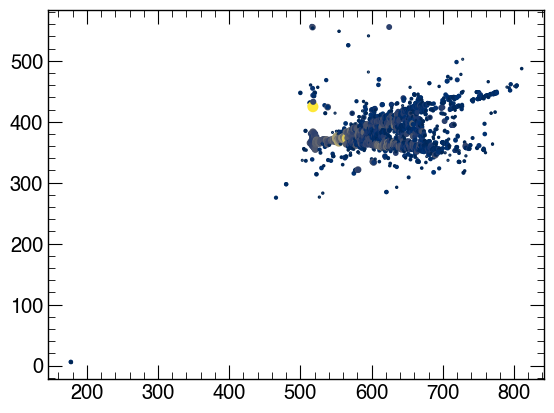

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8778,86745,4,3,0,2,19144,63079,7,-1,-1.0,...,257.235598,-353.074436,622.815134,9,"(1, 0, 2)",0,1,0,2,2421
8779,86745,4,3,3000,2,19147,408949,4,-1,-1.0,...,257.235598,-353.074436,622.815134,9,"(1, 0, 2)",3,1,0,2,2421
19049,86745,8,2,0,2,19150,21065,4,1,15107.0,...,257.235598,-353.074436,622.815134,16,"(0, 0, 4)",0,0,0,4,2422


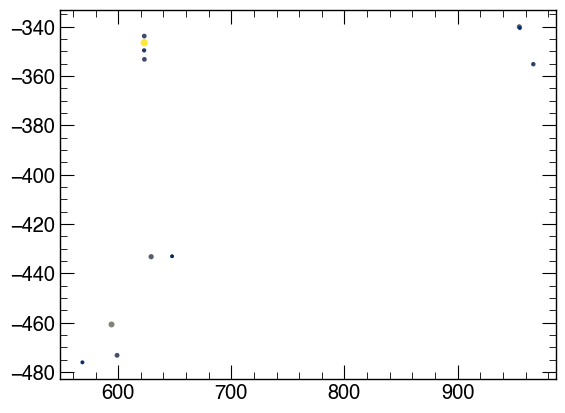

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
8804,86773,0,2,4000,2,19214,90790,16,-1,-1.0,...,-352.883413,-254.467217,147.973374,0,"(0, 0, 0)",4,0,0,0,2430
19067,86773,6,2,1000,2,19215,15856,2,1,15856.0,...,-352.883413,-254.467217,147.973374,12,"(0, 0, 3)",1,0,0,3,2431


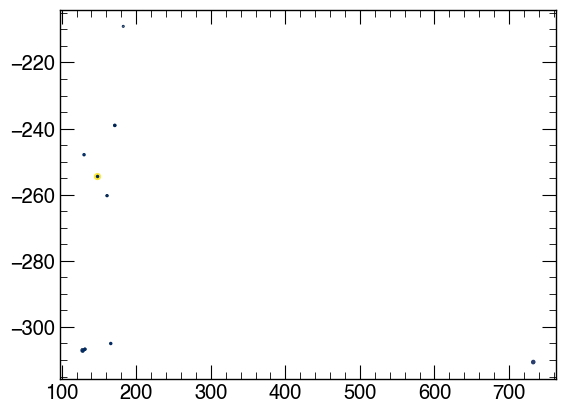

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
19222,87113,3,2,0,2,19811,44489,9,2,15632.0,...,-379.592326,149.543384,664.356933,6,"(0, 1, 1)",0,0,1,1,2500
19224,87113,7,2,2000,2,19813,35269,4,2,17634.5,...,-379.592326,149.543384,664.356933,14,"(0, 1, 3)",2,0,1,3,2501


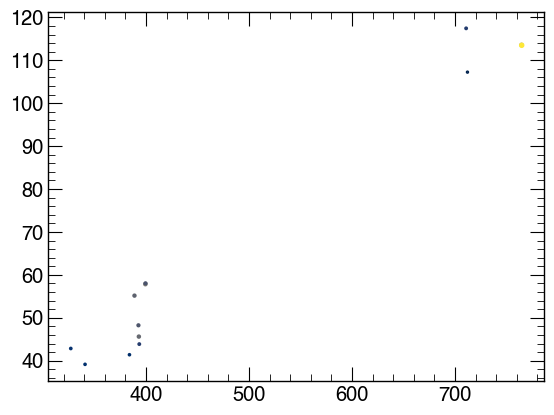

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9206,87359,1,3,4000,2,20129,1239733,147,-1,-1.0,...,369.38754,298.369105,162.739907,3,"(1, 1, 0)",4,1,1,0,2537
9207,87359,5,3,4000,2,20133,177490,18,-1,-1.0,...,369.38754,298.369105,162.739907,11,"(1, 1, 2)",4,1,1,2,2538
19313,87359,1,3,0,2,20127,18401,3,1,16224.0,...,369.38754,298.369105,162.739907,3,"(1, 1, 0)",0,1,1,0,2537


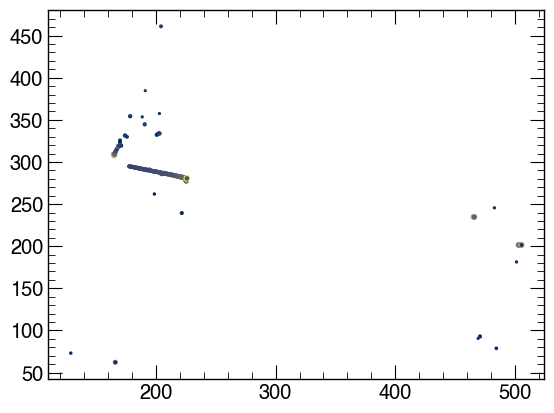

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9241,87400,2,2,4000,2,20203,780021,78,-1,-1.0,...,-365.387309,-313.576592,348.157155,4,"(0, 0, 1)",4,0,0,1,2549
19327,87400,6,2,4000,2,20206,42453,11,4,9539.0,...,-365.387309,-313.576592,348.157155,12,"(0, 0, 3)",4,0,0,3,2550


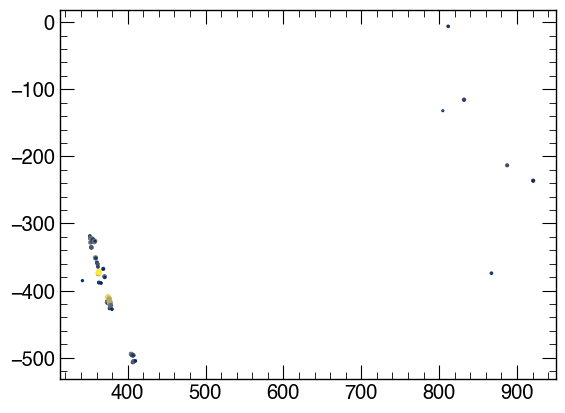

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9357,87793,6,2,0,2,20473,1128436,89,-1,-1.0,...,-103.810341,-580.579468,809.053233,12,"(0, 0, 3)",0,0,0,3,2582
9358,87793,6,2,1000,2,20474,1450204,43,-1,-1.0,...,-103.810341,-580.579468,809.053233,12,"(0, 0, 3)",1,0,0,3,2582
9359,87793,6,3,0,2,20476,66313,16,-1,-1.0,...,-103.810341,-580.579468,809.053233,13,"(1, 0, 3)",0,1,0,3,2582
9360,87793,8,2,2000,2,20478,70884,14,-1,-1.0,...,-103.810341,-580.579468,809.053233,16,"(0, 0, 4)",2,0,0,4,2582
19393,87793,2,2,0,2,20471,17617,3,1,17617.0,...,-103.810341,-580.579468,809.053233,4,"(0, 0, 1)",0,0,0,1,2581


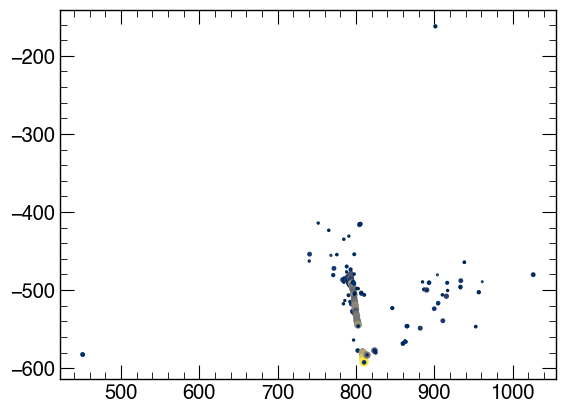

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9441,87850,0,2,4000,2,20651,967506,35,-1,-1.000000,...,-358.743601,-457.183232,32.19061,0,"(0, 0, 0)",4,0,0,0,2599
19435,87850,0,2,2000,2,20649,21152,3,1,21152.000000,...,-358.743601,-457.183232,32.19061,0,"(0, 0, 0)",2,0,0,0,2599
19436,87850,0,2,3000,2,20650,54982,13,3,14537.333333,...,-358.743601,-457.183232,32.19061,0,"(0, 0, 0)",3,0,0,0,2599
19438,87850,5,2,4000,2,20653,20890,4,1,20890.000000,...,-358.743601,-457.183232,32.19061,10,"(0, 1, 2)",4,0,1,2,2600


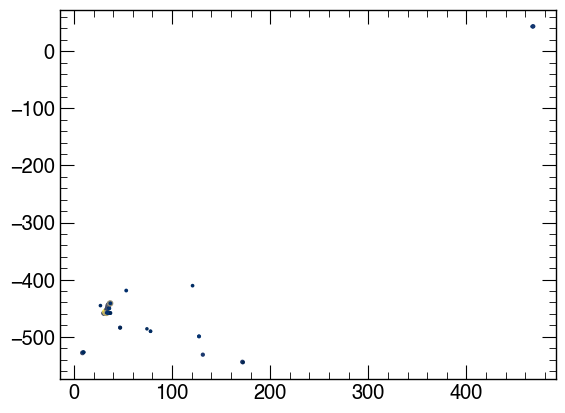

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9524,87993,1,3,0,2,20835,10584569,582,-1,-1.0,...,57.321162,265.411162,100.5419,3,"(1, 1, 0)",0,1,1,0,2621
9525,87993,3,3,0,2,20837,704526,73,-1,-1.0,...,57.321162,265.411162,100.5419,7,"(1, 1, 1)",0,1,1,1,2621
9526,87993,3,3,1000,2,20838,125143,21,-1,-1.0,...,57.321162,265.411162,100.5419,7,"(1, 1, 1)",1,1,1,1,2621
19480,87993,9,3,2000,2,20840,20438,4,1,15559.0,...,57.321162,265.411162,100.5419,19,"(1, 1, 4)",2,1,1,4,2622


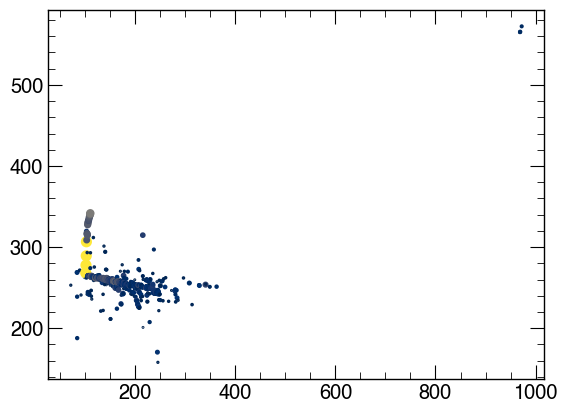

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9888,88744,11,2,3000,2,21666,1543880,142,-1,-1.0,...,-319.00447,47.939197,1361.380681,22,"(0, 1, 5)",3,0,1,5,2731
9889,88744,11,2,4000,2,21667,442329,54,-1,-1.0,...,-319.00447,47.939197,1361.380681,22,"(0, 1, 5)",4,0,1,5,2731
19697,88744,7,3,0,2,21661,17376,3,1,17376.0,...,-319.00447,47.939197,1361.380681,15,"(1, 1, 3)",0,1,1,3,2730
19698,88744,11,2,2000,2,21665,23684,3,1,23684.0,...,-319.00447,47.939197,1361.380681,22,"(0, 1, 5)",2,0,1,5,2731


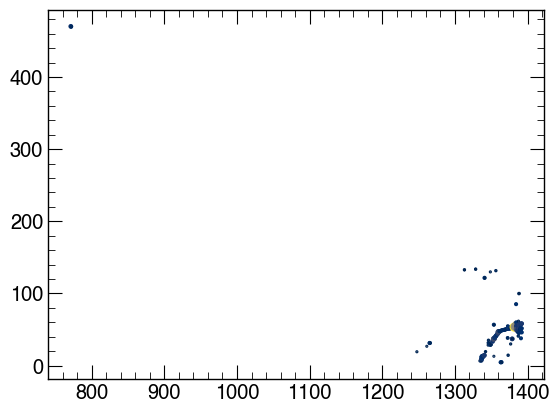

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
9896,88748,6,3,1000,2,21692,74504,16,-1,-1.0,...,189.610004,-595.439987,803.336808,13,"(1, 0, 3)",1,1,0,3,2736
9897,88748,6,3,2000,2,21693,10726942,623,-1,-1.0,...,189.610004,-595.439987,803.336808,13,"(1, 0, 3)",2,1,0,3,2736
9898,88748,8,3,2000,2,21695,285075,62,-1,-1.0,...,189.610004,-595.439987,803.336808,17,"(1, 0, 4)",2,1,0,4,2736
19708,88748,0,3,0,2,21688,21304,3,1,16512.0,...,189.610004,-595.439987,803.336808,1,"(1, 0, 0)",0,1,0,0,2735


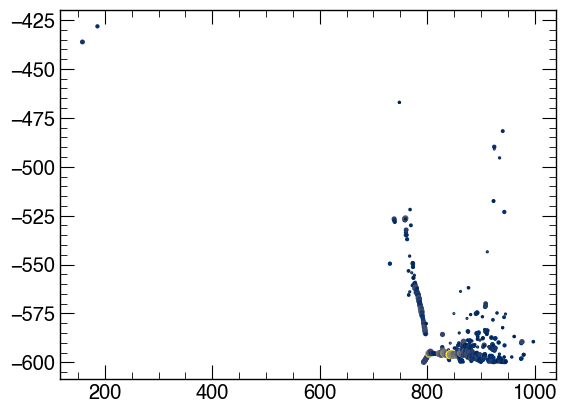

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
10077,89100,9,2,0,2,22143,4489873,276,-1,-1.0,...,-15.032277,223.46865,948.708466,18,"(0, 1, 4)",0,0,1,4,2787
10078,89100,9,3,0,2,22144,154841,27,-1,-1.0,...,-15.032277,223.46865,948.708466,19,"(1, 1, 4)",0,1,1,4,2787
10079,89100,9,3,1000,2,22145,123850,8,-1,-1.0,...,-15.032277,223.46865,948.708466,19,"(1, 1, 4)",1,1,1,4,2787
19844,89100,5,3,1000,2,22141,20801,3,1,15736.0,...,-15.032277,223.46865,948.708466,11,"(1, 1, 2)",1,1,1,2,2786


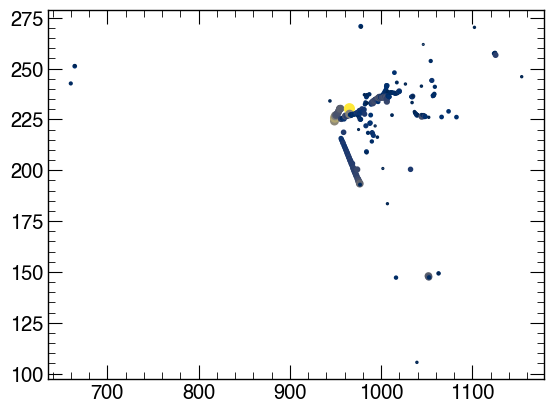

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
10167,89264,5,3,3000,2,22336,594705,26,-1,-1.0,...,278.270442,84.230659,538.171817,11,"(1, 1, 2)",3,1,1,2,2809
19899,89264,11,2,1000,2,22338,18232,5,2,9116.0,...,278.270442,84.230659,538.171817,22,"(0, 1, 5)",1,0,1,5,2810


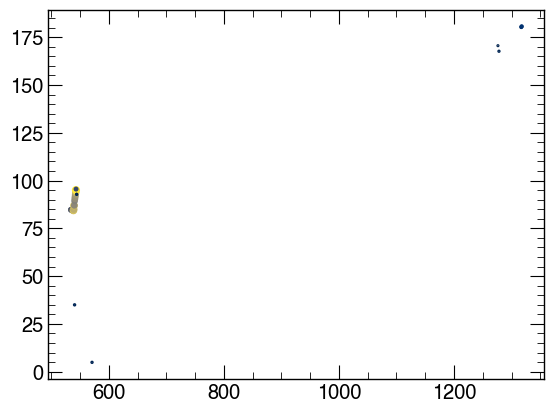

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
10589,89764,6,2,0,2,23238,364483,48,-1,-1.0,...,47.29262,-342.894313,758.197718,12,"(0, 0, 3)",0,0,0,3,2918
10590,89764,6,3,0,2,23240,17490345,1120,-1,-1.0,...,47.29262,-342.894313,758.197718,13,"(1, 0, 3)",0,1,0,3,2918
10591,89764,6,3,1000,2,23241,309195,54,-1,-1.0,...,47.29262,-342.894313,758.197718,13,"(1, 0, 3)",1,1,0,3,2918
10592,89764,8,2,0,2,23243,2462876,497,-1,-1.0,...,47.29262,-342.894313,758.197718,16,"(0, 0, 4)",0,0,0,4,2918
10593,89764,8,3,0,2,23245,628304,68,-1,-1.0,...,47.29262,-342.894313,758.197718,17,"(1, 0, 4)",0,1,0,4,2918
10594,89764,8,3,1000,2,23246,710494,109,-1,-1.0,...,47.29262,-342.894313,758.197718,17,"(1, 0, 4)",1,1,0,4,2918
10595,89764,10,2,0,2,23247,685262,67,-1,-1.0,...,47.29262,-342.894313,758.197718,20,"(0, 0, 5)",0,0,0,5,2918
10596,89764,10,2,1000,2,23248,86594,19,-1,-1.0,...,47.29262,-342.894313,758.197718,20,"(0, 0, 5)",1,0,0,5,2918
20117,89764,2,2,4000,2,23236,15027,3,1,15027.0,...,47.29262,-342.894313,758.197718,4,"(0, 0, 1)",4,0,0,1,2917
20118,89764,2,3,0,2,23237,16967,3,1,16967.0,...,47.29262,-342.894313,758.197718,5,"(1, 0, 1)",0,1,0,1,2917


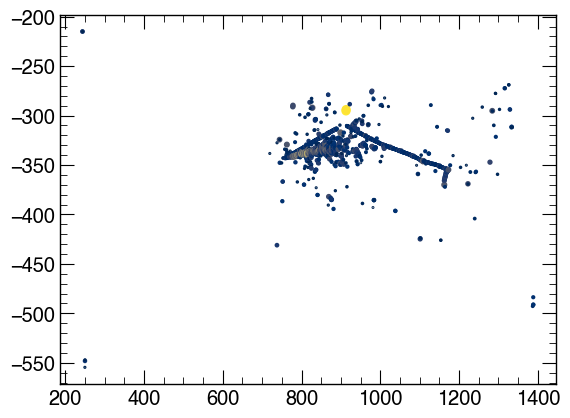

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
10601,89767,6,2,0,2,23260,4597890,244,-1,-1.0,...,6.500285,-431.362467,845.601251,12,"(0, 0, 3)",0,0,0,3,2922
10602,89767,6,3,0,2,23262,4631592,330,-1,-1.0,...,6.500285,-431.362467,845.601251,13,"(1, 0, 3)",0,1,0,3,2922
10603,89767,6,3,1000,2,23263,106080,19,-1,-1.0,...,6.500285,-431.362467,845.601251,13,"(1, 0, 3)",1,1,0,3,2922
10604,89767,8,2,0,2,23265,2487456,286,-1,-1.0,...,6.500285,-431.362467,845.601251,16,"(0, 0, 4)",0,0,0,4,2922
10605,89767,8,3,0,2,23266,385679,29,-1,-1.0,...,6.500285,-431.362467,845.601251,17,"(1, 0, 4)",0,1,0,4,2922
20124,89767,2,2,0,2,23259,23696,3,1,17377.0,...,6.500285,-431.362467,845.601251,4,"(0, 0, 1)",0,0,0,1,2921


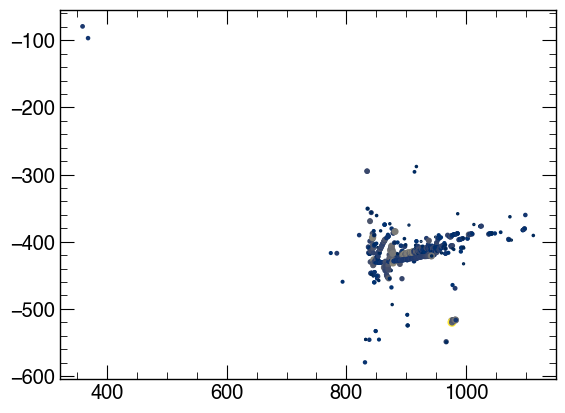

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
10830,90255,4,2,2000,2,23774,24361307,1581,-1,-1.000000,...,-234.955533,-138.078326,526.069094,8,"(0, 0, 2)",2,0,0,2,2988
10831,90255,4,2,3000,2,23775,3110392,445,-1,-1.000000,...,-234.955533,-138.078326,526.069094,8,"(0, 0, 2)",3,0,0,2,2988
10832,90255,4,2,4000,2,23776,75610,22,-1,-1.000000,...,-234.955533,-138.078326,526.069094,8,"(0, 0, 2)",4,0,0,2,2988
10833,90255,5,2,2000,2,23777,64822,17,-1,-1.000000,...,-234.955533,-138.078326,526.069094,10,"(0, 1, 2)",2,0,1,2,2988
10834,90255,6,2,2000,2,23782,941832,162,-1,-1.000000,...,-234.955533,-138.078326,526.069094,12,"(0, 0, 3)",2,0,0,3,2988
10835,90255,6,2,3000,2,23783,136939,31,-1,-1.000000,...,-234.955533,-138.078326,526.069094,12,"(0, 0, 3)",3,0,0,3,2988
10836,90255,6,2,4000,2,23784,86116,25,-1,-1.000000,...,-234.955533,-138.078326,526.069094,12,"(0, 0, 3)",4,0,0,3,2988
10837,90255,7,2,2000,2,23788,247329,35,-1,-1.000000,...,-234.955533,-138.078326,526.069094,14,"(0, 1, 3)",2,0,1,3,2988
10838,90255,10,3,1000,2,23795,55829,4,-1,-1.000000,...,-234.955533,-138.078326,526.069094,21,"(1, 0, 5)",1,1,0,5,2989
10839,90255,10,3,2000,2,23796,175268,11,-1,-1.000000,...,-234.955533,-138.078326,526.069094,21,"(1, 0, 5)",2,1,0,5,2989


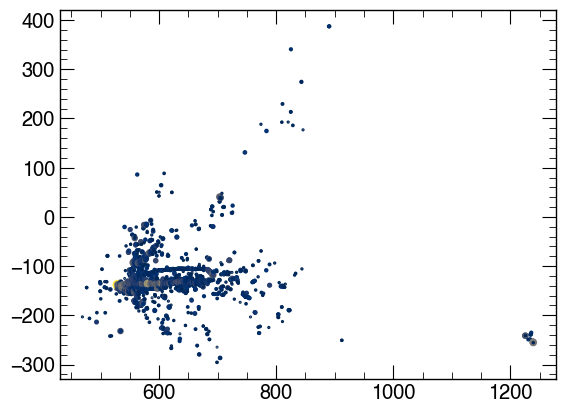

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
11101,90663,4,3,1000,2,24391,361783,24,-1,-1.0,...,134.977418,-280.584877,622.815134,9,"(1, 0, 2)",1,1,0,2,3066
20420,90663,0,3,0,2,24390,21790,4,2,10895.0,...,134.977418,-280.584877,622.815134,1,"(1, 0, 0)",0,1,0,0,3065
20421,90663,6,3,2000,2,24393,25866,6,1,22926.0,...,134.977418,-280.584877,622.815134,13,"(1, 0, 3)",2,1,0,3,3066


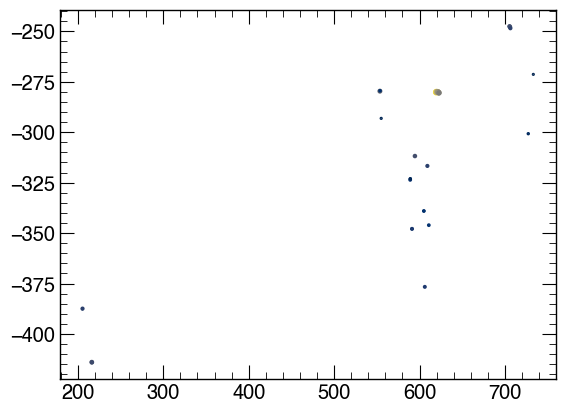

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
11182,90727,0,2,1000,2,24568,887290,143,-1,-1.0,...,-104.854816,-388.398976,185.411967,0,"(0, 0, 0)",1,0,0,0,3090
11183,90727,2,2,1000,2,24570,4511110,327,-1,-1.0,...,-104.854816,-388.398976,185.411967,4,"(0, 0, 1)",1,0,0,1,3090
11184,90727,2,2,2000,2,24571,93749,20,-1,-1.0,...,-104.854816,-388.398976,185.411967,4,"(0, 0, 1)",2,0,0,1,3090
20467,90727,2,2,0,2,24569,21069,6,2,9866.0,...,-104.854816,-388.398976,185.411967,4,"(0, 0, 1)",0,0,0,1,3090
20469,90727,9,3,4000,2,24575,16231,3,1,16231.0,...,-104.854816,-388.398976,185.411967,19,"(1, 1, 4)",4,1,1,4,3091


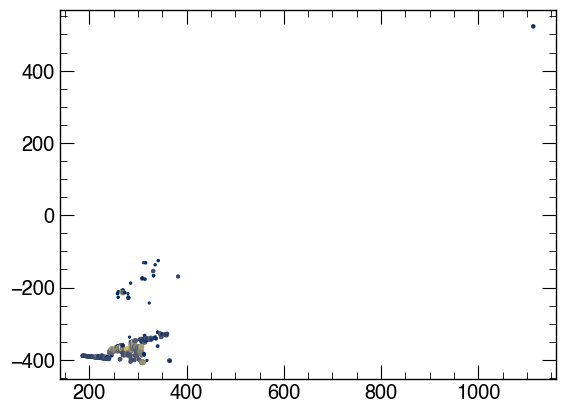

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
11328,90978,3,2,2000,2,24874,489427,35,-1,-1.0,...,-208.469893,307.422962,409.729784,6,"(0, 1, 1)",2,0,1,1,3130
20537,90978,9,2,1000,2,24879,22595,3,1,16361.0,...,-208.469893,307.422962,409.729784,18,"(0, 1, 4)",1,0,1,4,3131


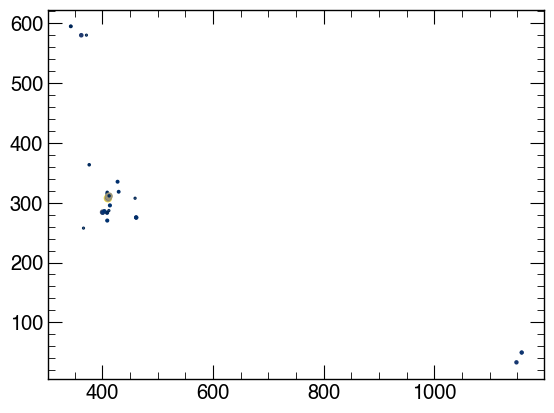

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
11369,90992,4,3,2000,2,24967,6147111,494,-1,-1.0,...,228.510788,-295.128303,567.290005,9,"(1, 0, 2)",2,1,0,2,3146
11370,90992,4,3,3000,2,24968,3519188,370,-1,-1.0,...,228.510788,-295.128303,567.290005,9,"(1, 0, 2)",3,1,0,2,3146
11371,90992,4,3,4000,2,24969,486584,42,-1,-1.0,...,228.510788,-295.128303,567.290005,9,"(1, 0, 2)",4,1,0,2,3146
11372,90992,6,3,1000,2,24971,476115,15,-1,-1.0,...,228.510788,-295.128303,567.290005,13,"(1, 0, 3)",1,1,0,3,3146
11373,90992,6,3,2000,2,24972,6255508,833,-1,-1.0,...,228.510788,-295.128303,567.290005,13,"(1, 0, 3)",2,1,0,3,3146
11374,90992,6,3,3000,2,24973,1023386,106,-1,-1.0,...,228.510788,-295.128303,567.290005,13,"(1, 0, 3)",3,1,0,3,3146
11375,90992,8,3,1000,2,24976,1153180,156,-1,-1.0,...,228.510788,-295.128303,567.290005,17,"(1, 0, 4)",1,1,0,4,3146
11376,90992,8,3,2000,2,24977,16040262,1248,-1,-1.0,...,228.510788,-295.128303,567.290005,17,"(1, 0, 4)",2,1,0,4,3146
11377,90992,8,3,3000,2,24978,1721450,230,-1,-1.0,...,228.510788,-295.128303,567.290005,17,"(1, 0, 4)",3,1,0,4,3146
11378,90992,10,3,3000,2,24982,270105,57,-1,-1.0,...,228.510788,-295.128303,567.290005,21,"(1, 0, 5)",3,1,0,5,3146


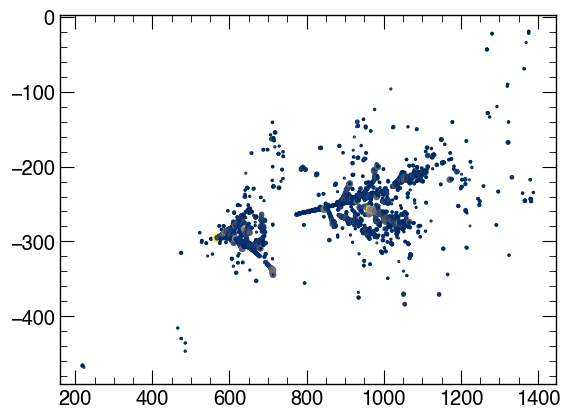

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
11456,91032,0,2,3000,2,25157,7362235,476,-1,-1.0,...,-342.083456,-515.243589,35.8863,0,"(0, 0, 0)",3,0,0,0,3166
11457,91032,0,2,4000,2,25158,48923818,1009,-1,-1.0,...,-342.083456,-515.243589,35.8863,0,"(0, 0, 0)",4,0,0,0,3166
11458,91032,2,2,3000,2,25160,704394,131,-1,-1.0,...,-342.083456,-515.243589,35.8863,4,"(0, 0, 1)",3,0,0,1,3166
11459,91032,2,2,4000,2,25161,748600,129,-1,-1.0,...,-342.083456,-515.243589,35.8863,4,"(0, 0, 1)",4,0,0,1,3166
11460,91032,9,2,3000,2,25163,279616,24,-1,-1.0,...,-342.083456,-515.243589,35.8863,18,"(0, 1, 4)",3,0,1,4,3167
11461,91032,9,2,4000,2,25164,258555,18,-1,-1.0,...,-342.083456,-515.243589,35.8863,18,"(0, 1, 4)",4,0,1,4,3167


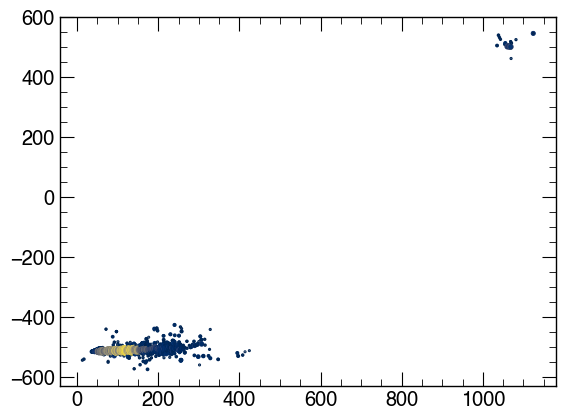

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
12157,92154,7,2,1000,2,26768,110728,29,-1,-1.0,...,-109.725891,157.238494,963.681273,14,"(0, 1, 3)",1,0,1,3,3350
12158,92154,9,2,0,2,26774,3111659,323,-1,-1.0,...,-109.725891,157.238494,963.681273,18,"(0, 1, 4)",0,0,1,4,3350
12159,92154,9,2,1000,2,26775,20637115,1720,-1,-1.0,...,-109.725891,157.238494,963.681273,18,"(0, 1, 4)",1,0,1,4,3350
12160,92154,9,2,2000,2,26776,138991,32,-1,-1.0,...,-109.725891,157.238494,963.681273,18,"(0, 1, 4)",2,0,1,4,3350
12161,92154,11,2,0,2,26783,2001215,163,-1,-1.0,...,-109.725891,157.238494,963.681273,22,"(0, 1, 5)",0,0,1,5,3350
12162,92154,11,2,1000,2,26784,22864741,1588,-1,-1.0,...,-109.725891,157.238494,963.681273,22,"(0, 1, 5)",1,0,1,5,3350
12163,92154,11,2,2000,2,26785,1581412,205,-1,-1.0,...,-109.725891,157.238494,963.681273,22,"(0, 1, 5)",2,0,1,5,3350
12164,92154,11,3,0,2,26788,162106,34,-1,-1.0,...,-109.725891,157.238494,963.681273,23,"(1, 1, 5)",0,1,1,5,3350
21032,92154,1,3,4000,2,26763,26085,4,1,26085.0,...,-109.725891,157.238494,963.681273,3,"(1, 1, 0)",4,1,1,0,3349
21034,92154,7,2,0,2,26767,19134,5,1,15247.0,...,-109.725891,157.238494,963.681273,14,"(0, 1, 3)",0,0,1,3,3350


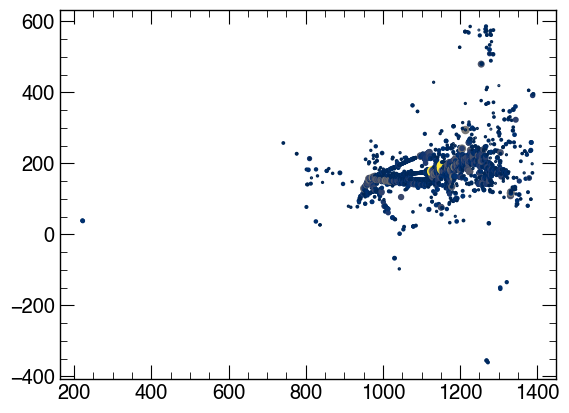

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
12176,92157,5,3,0,2,26811,3544404,302,-1,-1.0,...,96.323963,524.242246,599.563408,11,"(1, 1, 2)",0,1,1,2,3353
12177,92157,5,3,1000,2,26812,9653837,703,-1,-1.0,...,96.323963,524.242246,599.563408,11,"(1, 1, 2)",1,1,1,2,3353
12178,92157,7,3,0,2,26817,525625,64,-1,-1.0,...,96.323963,524.242246,599.563408,15,"(1, 1, 3)",0,1,1,3,3353
12179,92157,7,3,1000,2,26818,4848296,531,-1,-1.0,...,96.323963,524.242246,599.563408,15,"(1, 1, 3)",1,1,1,3,3353
12180,92157,7,3,2000,2,26819,1283496,159,-1,-1.0,...,96.323963,524.242246,599.563408,15,"(1, 1, 3)",2,1,1,3,3353
12181,92157,11,3,0,2,26822,381429,41,-1,-1.0,...,96.323963,524.242246,599.563408,23,"(1, 1, 5)",0,1,1,5,3354
12182,92157,11,3,1000,2,26823,6753467,462,-1,-1.0,...,96.323963,524.242246,599.563408,23,"(1, 1, 5)",1,1,1,5,3354
12183,92157,11,3,2000,2,26824,1180402,130,-1,-1.0,...,96.323963,524.242246,599.563408,23,"(1, 1, 5)",2,1,1,5,3354
21044,92157,3,3,0,2,26808,31251,6,2,12194.0,...,96.323963,524.242246,599.563408,7,"(1, 1, 1)",0,1,1,1,3353


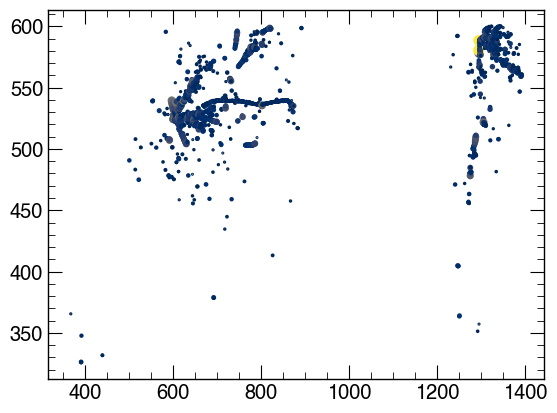

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
12372,92321,1,2,1000,2,27249,99421,11,-1,-1.0,...,-210.808277,334.041286,104.412412,2,"(0, 1, 0)",1,0,1,0,3406
12373,92321,1,2,2000,2,27250,1455088,132,-1,-1.0,...,-210.808277,334.041286,104.412412,2,"(0, 1, 0)",2,0,1,0,3406
12374,92321,1,2,3000,2,27251,923305,45,-1,-1.0,...,-210.808277,334.041286,104.412412,2,"(0, 1, 0)",3,0,1,0,3406
12375,92321,1,2,4000,2,27252,551533,31,-1,-1.0,...,-210.808277,334.041286,104.412412,2,"(0, 1, 0)",4,0,1,0,3406
12376,92321,3,2,2000,2,27256,2303441,273,-1,-1.0,...,-210.808277,334.041286,104.412412,6,"(0, 1, 1)",2,0,1,1,3406
12377,92321,5,2,1000,2,27259,257123,7,-1,-1.0,...,-210.808277,334.041286,104.412412,10,"(0, 1, 2)",1,0,1,2,3406
12378,92321,5,2,2000,2,27260,1444217,166,-1,-1.0,...,-210.808277,334.041286,104.412412,10,"(0, 1, 2)",2,0,1,2,3406
12379,92321,11,3,1000,2,27268,60137,8,-1,-1.0,...,-210.808277,334.041286,104.412412,23,"(1, 1, 5)",1,1,1,5,3407
21160,92321,3,2,3000,2,27257,22008,7,2,11004.0,...,-210.808277,334.041286,104.412412,6,"(0, 1, 1)",3,0,1,1,3406
21165,92321,11,3,0,2,27267,50869,12,2,10911.5,...,-210.808277,334.041286,104.412412,23,"(1, 1, 5)",0,1,1,5,3407


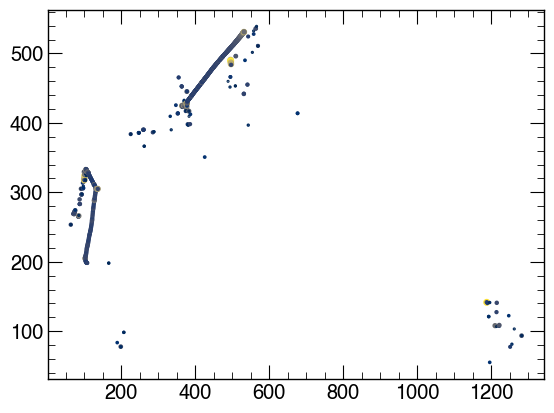

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
21388,92791,3,2,4000,2,28170,16497,4,1,16497.0,...,283.513958,-184.695527,996.372541,6,"(0, 1, 1)",4,0,1,1,3521
21390,92791,8,3,4000,2,28173,21938,5,1,21121.0,...,283.513958,-184.695527,996.372541,17,"(1, 0, 4)",4,1,0,4,3522


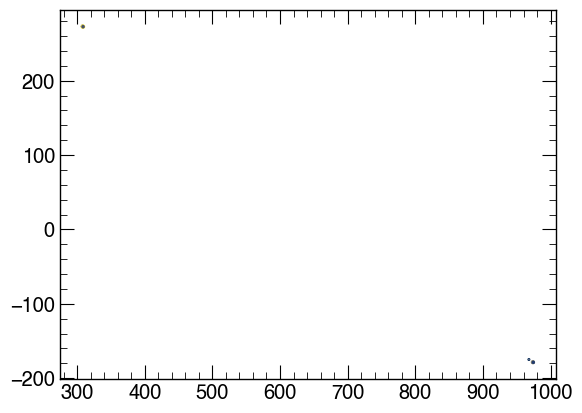

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
12856,92812,2,2,2000,2,28330,81553,22,-1,-1.0,...,-290.740923,-300.462001,361.71057,4,"(0, 0, 1)",2,0,0,1,3543
12857,92812,2,2,3000,2,28331,1099537,77,-1,-1.0,...,-290.740923,-300.462001,361.71057,4,"(0, 0, 1)",3,0,0,1,3543
21434,92812,6,3,0,2,28334,20928,3,1,15511.0,...,-290.740923,-300.462001,361.71057,13,"(1, 0, 3)",0,1,0,3,3544


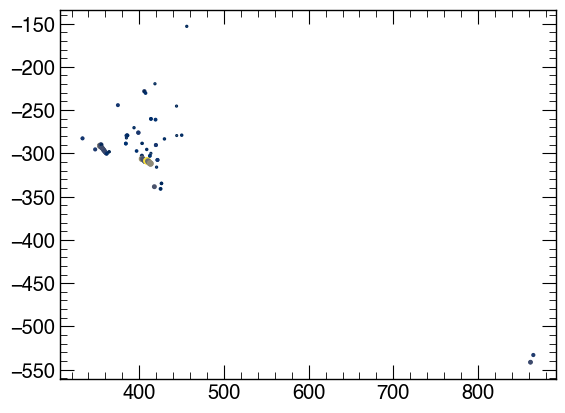

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
13421,93669,0,3,0,2,29569,903573,71,-1,-1.0,...,167.522584,-449.716207,29.507729,1,"(1, 0, 0)",0,1,0,0,3709
13422,93669,0,3,1000,2,29570,22022451,889,-1,-1.0,...,167.522584,-449.716207,29.507729,1,"(1, 0, 0)",1,1,0,0,3709
13423,93669,0,3,2000,2,29571,26910195,1329,-1,-1.0,...,167.522584,-449.716207,29.507729,1,"(1, 0, 0)",2,1,0,0,3709
13424,93669,0,3,3000,2,29572,83793,17,-1,-1.0,...,167.522584,-449.716207,29.507729,1,"(1, 0, 0)",3,1,0,0,3709
13425,93669,2,3,0,2,29575,1931059,115,-1,-1.0,...,167.522584,-449.716207,29.507729,5,"(1, 0, 1)",0,1,0,1,3709
13426,93669,2,3,1000,2,29576,14552611,1458,-1,-1.0,...,167.522584,-449.716207,29.507729,5,"(1, 0, 1)",1,1,0,1,3709
13427,93669,2,3,2000,2,29577,10207013,1379,-1,-1.0,...,167.522584,-449.716207,29.507729,5,"(1, 0, 1)",2,1,0,1,3709
13428,93669,2,3,3000,2,29578,81698,25,-1,-1.0,...,167.522584,-449.716207,29.507729,5,"(1, 0, 1)",3,1,0,1,3709
13429,93669,4,2,0,2,29582,55018,10,-1,-1.0,...,167.522584,-449.716207,29.507729,8,"(0, 0, 2)",0,0,0,2,3709
13430,93669,4,3,0,2,29584,71693,17,-1,-1.0,...,167.522584,-449.716207,29.507729,9,"(1, 0, 2)",0,1,0,2,3709


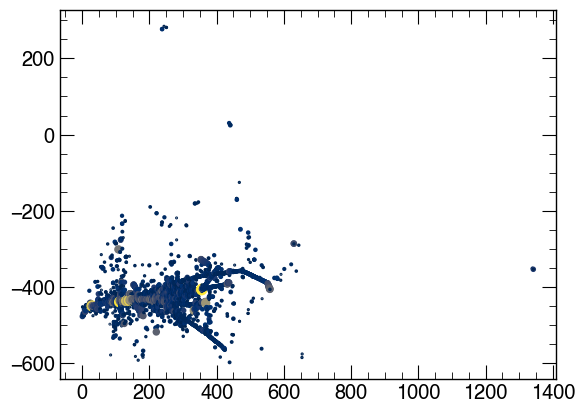

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
13636,93827,5,2,3000,2,30034,933626,148,-1,-1.0,...,-379.855676,508.049947,524.107152,10,"(0, 1, 2)",3,0,1,2,3765
13637,93827,5,2,4000,2,30035,7763075,529,-1,-1.0,...,-379.855676,508.049947,524.107152,10,"(0, 1, 2)",4,0,1,2,3765
13638,93827,11,2,3000,2,30039,482023,36,-1,-1.0,...,-379.855676,508.049947,524.107152,22,"(0, 1, 5)",3,0,1,5,3766
13639,93827,11,2,4000,2,30040,300647,8,-1,-1.0,...,-379.855676,508.049947,524.107152,22,"(0, 1, 5)",4,0,1,5,3766


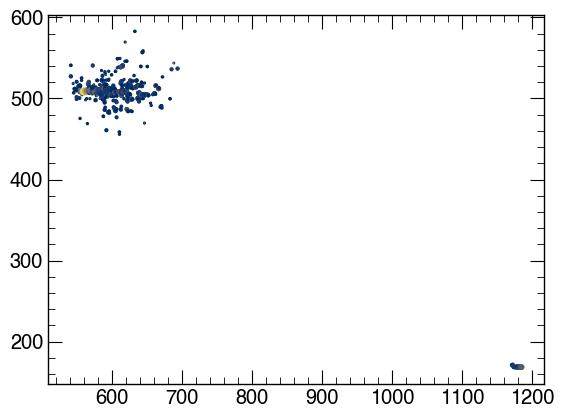

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
13725,94175,10,2,0,2,30243,67131,15,-1,-1.0,...,34.356895,-422.092136,1336.728056,20,"(0, 0, 5)",0,0,0,5,3795
13726,94175,10,3,0,2,30244,3069194,173,-1,-1.0,...,34.356895,-422.092136,1336.728056,21,"(1, 0, 5)",0,1,0,5,3795
13727,94175,10,3,1000,2,30245,80612,17,-1,-1.0,...,34.356895,-422.092136,1336.728056,21,"(1, 0, 5)",1,1,0,5,3795
21923,94175,1,3,1000,2,30242,32031,5,2,16015.5,...,34.356895,-422.092136,1336.728056,3,"(1, 1, 0)",1,1,1,0,3794


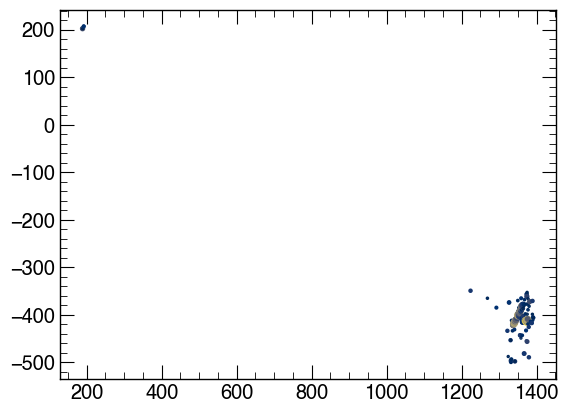

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
13984,94563,7,3,2000,2,30775,77687,20,-1,-1.0,...,288.143227,256.945162,818.393872,15,"(1, 1, 3)",2,1,1,3,3869
13985,94563,7,3,3000,2,30776,4663475,382,-1,-1.0,...,288.143227,256.945162,818.393872,15,"(1, 1, 3)",3,1,1,3,3869
13986,94563,7,3,4000,2,30777,361285,49,-1,-1.0,...,288.143227,256.945162,818.393872,15,"(1, 1, 3)",4,1,1,3,3869
13987,94563,9,3,2000,2,30779,59634,14,-1,-1.0,...,288.143227,256.945162,818.393872,19,"(1, 1, 4)",2,1,1,4,3869
13988,94563,9,3,4000,2,30781,73738,20,-1,-1.0,...,288.143227,256.945162,818.393872,19,"(1, 1, 4)",4,1,1,4,3869
22033,94563,1,2,1000,2,30771,19719,3,1,16434.0,...,288.143227,256.945162,818.393872,2,"(0, 1, 0)",1,0,1,0,3868
22034,94563,7,2,0,2,30773,20814,4,1,16289.0,...,288.143227,256.945162,818.393872,14,"(0, 1, 3)",0,0,1,3,3869


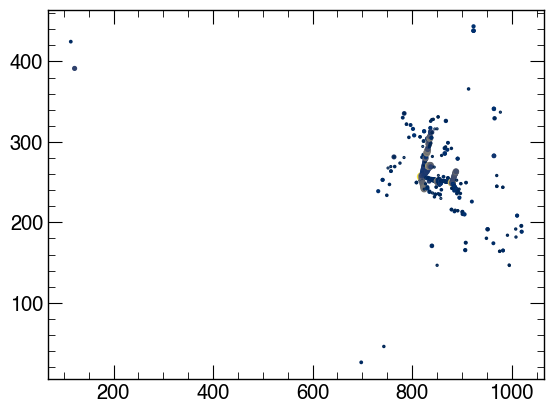

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
14101,94792,0,2,0,2,31026,229904,42,-1,-1.0,...,-67.340269,36.690288,0.304244,0,"(0, 0, 0)",0,0,0,0,3898
14102,94792,0,2,1000,2,31027,84084,12,-1,-1.0,...,-67.340269,36.690288,0.304244,0,"(0, 0, 0)",1,0,0,0,3898
14103,94792,0,2,2000,2,31028,66575,20,-1,-1.0,...,-67.340269,36.690288,0.304244,0,"(0, 0, 0)",2,0,0,0,3898
14104,94792,0,3,0,2,31030,68483,19,-1,-1.0,...,-67.340269,36.690288,0.304244,1,"(1, 0, 0)",0,1,0,0,3898
14105,94792,1,2,0,2,31032,51122037,2568,-1,-1.0,...,-67.340269,36.690288,0.304244,2,"(0, 1, 0)",0,0,1,0,3898
14106,94792,1,2,1000,2,31033,2427053,255,-1,-1.0,...,-67.340269,36.690288,0.304244,2,"(0, 1, 0)",1,0,1,0,3898
14107,94792,1,3,0,2,31037,1401799,73,-1,-1.0,...,-67.340269,36.690288,0.304244,3,"(1, 1, 0)",0,1,1,0,3898
14108,94792,2,2,0,2,31039,704721,54,-1,-1.0,...,-67.340269,36.690288,0.304244,4,"(0, 0, 1)",0,0,0,1,3898
14109,94792,2,2,1000,2,31040,79599,17,-1,-1.0,...,-67.340269,36.690288,0.304244,4,"(0, 0, 1)",1,0,0,1,3898
14110,94792,3,2,0,2,31045,15517961,1065,-1,-1.0,...,-67.340269,36.690288,0.304244,6,"(0, 1, 1)",0,0,1,1,3898


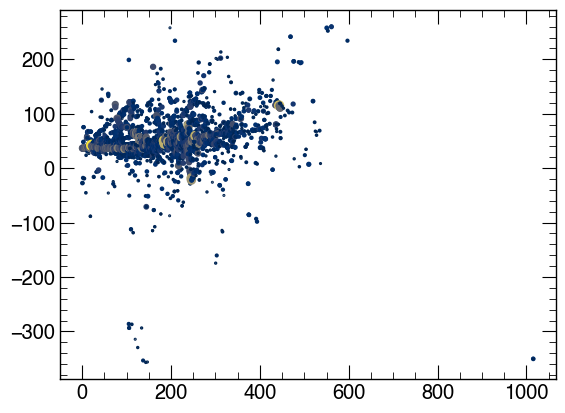

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
14152,94814,7,2,0,2,31135,5053576,583,-1,-1.0,...,0.288626,221.900156,837.987482,14,"(0, 1, 3)",0,0,1,3,3912
14153,94814,7,2,1000,2,31136,112804,27,-1,-1.0,...,0.288626,221.900156,837.987482,14,"(0, 1, 3)",1,0,1,3,3912
14154,94814,7,3,0,2,31138,9850590,335,-1,-1.0,...,0.288626,221.900156,837.987482,15,"(1, 1, 3)",0,1,1,3,3912
14155,94814,7,3,1000,2,31139,95992,25,-1,-1.0,...,0.288626,221.900156,837.987482,15,"(1, 1, 3)",1,1,1,3,3912
14156,94814,8,2,0,2,31141,160522,6,-1,-1.0,...,0.288626,221.900156,837.987482,16,"(0, 0, 4)",0,0,0,4,3912
14157,94814,9,2,0,2,31142,11228058,1223,-1,-1.0,...,0.288626,221.900156,837.987482,18,"(0, 1, 4)",0,0,1,4,3912
14158,94814,9,2,1000,2,31143,136428,26,-1,-1.0,...,0.288626,221.900156,837.987482,18,"(0, 1, 4)",1,0,1,4,3912
14159,94814,9,3,0,2,31147,19365585,1386,-1,-1.0,...,0.288626,221.900156,837.987482,19,"(1, 1, 4)",0,1,1,4,3912
14160,94814,11,3,0,2,31154,365879,61,-1,-1.0,...,0.288626,221.900156,837.987482,23,"(1, 1, 5)",0,1,1,5,3912
22124,94814,3,3,0,2,31128,16618,4,1,16618.0,...,0.288626,221.900156,837.987482,7,"(1, 1, 1)",0,1,1,1,3911


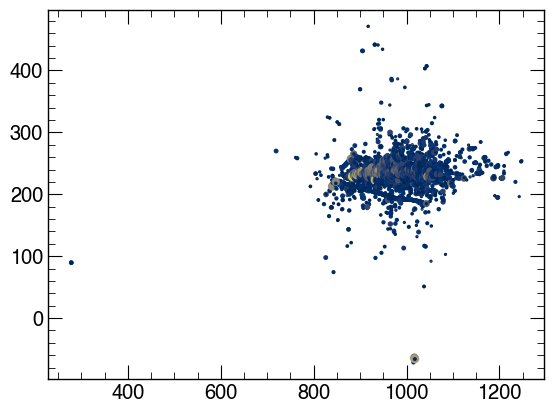

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,x,y,z,tpc,voxel,it,ix,iy,iz,TC_id
14325,94989,5,2,0,2,31525,12439833,877,-1,-1.0,...,0.288715,191.754704,540.537555,10,"(0, 1, 2)",0,0,1,2,3956
14326,94989,5,2,1000,2,31526,88621,14,-1,-1.0,...,0.288715,191.754704,540.537555,10,"(0, 1, 2)",1,0,1,2,3956
14327,94989,5,2,2000,2,31527,76442,14,-1,-1.0,...,0.288715,191.754704,540.537555,10,"(0, 1, 2)",2,0,1,2,3956
14328,94989,5,3,0,2,31528,6572522,615,-1,-1.0,...,0.288715,191.754704,540.537555,11,"(1, 1, 2)",0,1,1,2,3956
14329,94989,5,3,1000,2,31529,218950,30,-1,-1.0,...,0.288715,191.754704,540.537555,11,"(1, 1, 2)",1,1,1,2,3956
14330,94989,7,2,0,2,31532,6544080,759,-1,-1.0,...,0.288715,191.754704,540.537555,14,"(0, 1, 3)",0,0,1,3,3956
14331,94989,7,2,1000,2,31533,99324,24,-1,-1.0,...,0.288715,191.754704,540.537555,14,"(0, 1, 3)",1,0,1,3,3956
14332,94989,7,3,0,2,31535,3221246,360,-1,-1.0,...,0.288715,191.754704,540.537555,15,"(1, 1, 3)",0,1,1,3,3956
22213,94989,0,3,1000,2,31514,15139,2,1,15139.0,...,0.288715,191.754704,540.537555,1,"(1, 0, 0)",1,1,0,0,3955
22214,94989,1,2,0,2,31515,22087,3,1,17716.0,...,0.288715,191.754704,540.537555,2,"(0, 1, 0)",0,0,1,0,3955


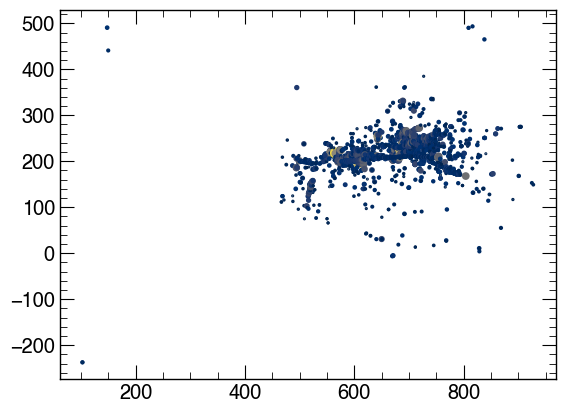

In [339]:
event =77334#94175 
for event in split_events:
    x =tps_c[(tps_c.event==event) & (tps_c.bt_edep>0)]

    plt.scatter(x.bt_z, x.bt_y, c=x.adc_peak, s= x.adc_peak/300)
    display(tas_c[tas_c.event== event])
    plt.show()

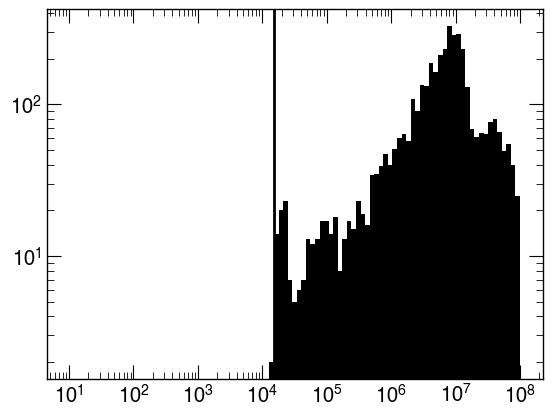

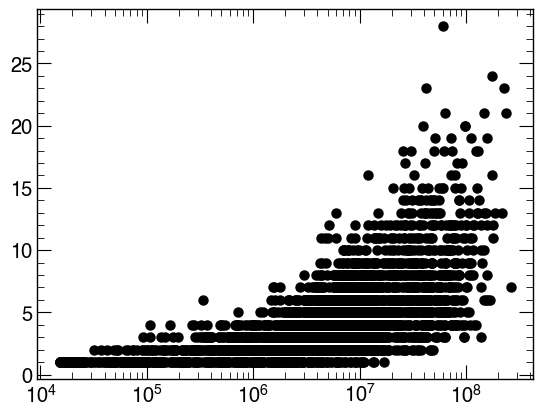

In [304]:
plt.hist(tcs.groupby("TC_id").total_window_energy.sum(), bins = np.logspace(1, 8, 100))
plt.xscale('log')
plt.axvline(15e3)
plt.yscale('log')
plt.show()
plt.scatter(tcs.groupby("TC_id").total_window_energy.sum(), tcs.groupby("TC_id").TA_id.nunique())
plt.xscale('log')

In [261]:
#only the triggered widnows 
tas_c = tas_c[tas_c.flag==2]
tps_c = tps_c[tps_c.TA_id.isin(tas_c.TA_id.unique())]

In [262]:
tas_c

,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,...,ch_wmean,t_wmean,ch_wstd,t_wstd,visible_energy,mode,ccnc,x,y,z
0,36531,9,2,3000,2,1,4248852,359,-1,-1.000000,...,24870.482956,3336.626090,63.791761,61.887231,1212.774897,0,0,-269.369349,573.900570,989.457273
1,36532,5,3,3000,2,4,942853,91,-1,-1.000000,...,15272.763557,3732.874318,83.784611,226.237538,921.056906,1,0,343.518783,46.030703,674.763913
2,36532,5,3,4000,2,5,1120359,102,-1,-1.000000,...,15314.942570,4202.131024,23.823450,68.785863,921.056906,1,0,343.518783,46.030703,674.763913
3,36532,7,3,4000,2,6,741689,141,-1,-1.000000,...,20068.635802,4388.743395,39.031621,61.473434,921.056906,1,0,343.518783,46.030703,674.763913
4,36533,5,3,3000,2,9,282788,23,-1,-1.000000,...,15194.431907,3881.068465,72.264459,152.348159,196.238387,10,1,318.652756,92.123193,622.815134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22206,94985,4,3,1000,2,31482,54602,13,3,10254.333333,...,12749.728353,1739.535505,1.053303,1.011568,1515.820653,2,1,106.166414,-275.999624,191.417932
22211,94986,9,3,2000,2,31496,52525,14,5,9169.400000,...,25431.815952,2994.983610,1.080076,3.341202,2281.389142,2,0,343.557534,230.142256,925.191757
22213,94989,0,3,1000,2,31514,15139,2,1,15139.000000,...,2293.312768,1012.000000,0.463621,0.000000,8289.347081,2,1,0.288715,191.754704,540.537555
22214,94989,1,2,0,2,31515,22087,3,1,17716.000000,...,4467.901163,331.296512,0.298443,0.895330,8289.347081,2,1,0.288715,191.754704,540.537555


In [263]:
print(evsum[evsum.visible_energy > 0].event.nunique())
tas_c.event.nunique()

3988


3888

In [264]:
keys = tas_c[['event', 'apa_id', 'rop']].drop_duplicates()

matched_energy = (
    ide.merge(keys,left_on=['event', 'apa_id', 'readout_plane_id'], right_on=['event', 'apa_id', 'rop'],how='inner').groupby('event', as_index=False)['energy_per_tpc'].sum().rename(columns={'energy_per_tpc': 'matched_energy'}))

energy_sum = (evsum[['event']].drop_duplicates().merge(matched_energy, on='event', how='left').fillna({'matched_energy_per_tpc': 0}))

df = energy_sum
total_vis = ide.groupby("event", as_index=False)["total_visible_energy"].first()
df = energy_sum.merge(total_vis, on="event", how="left")
df = df.merge(nu[['ccnc','x','y','z', 'event']], on="event")

df["ratio"] = df["matched_energy"] / df["total_visible_energy"]
df =df[df.total_visible_energy > 0]
df["in_fv"] = ((df["x"].abs() < 360) & (df["y"].abs() < 600) &(df["z"] > 0) &(df["z"] < 1380))
df

,event,matched_energy,total_visible_energy,ccnc,x,y,z,ratio,in_fv
0,73291,4213.695801,4340.495117,0,-158.384604,58.441930,1037.149135,0.970787,True
1,73292,4695.205078,4740.705078,0,-134.680114,514.371090,1302.675255,0.990402,True
2,73293,5157.795898,5164.923828,0,-98.618235,562.667070,140.633797,0.998620,True
3,73294,6289.179688,6293.520996,0,108.202243,-175.723307,267.559645,0.999310,True
4,73295,34671.308594,34671.351562,1,27.907082,-541.669600,708.620100,0.999999,True
...,...,...,...,...,...,...,...,...,...
3983,91266,3645.080566,3651.773682,0,146.345006,452.446624,99.262885,0.998167,True
3984,91267,1507.020508,1507.020508,0,270.008948,-141.849331,1085.248208,1.000000,True
3985,91268,7946.682129,7958.342773,0,-47.611149,-584.263695,244.010293,0.998535,True
3986,91269,6.120989,28.658903,1,202.407113,556.281842,1027.676651,0.213581,True


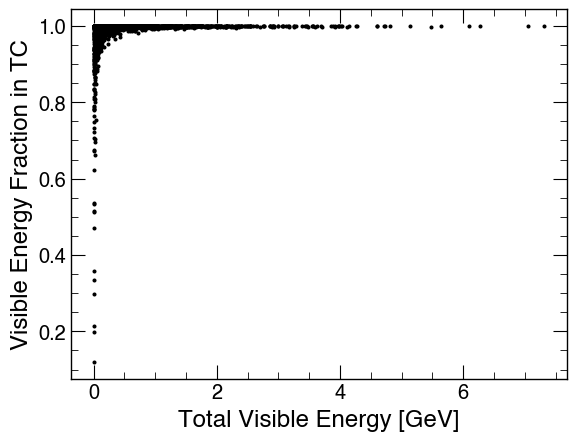

Text(0, 0.5, 'Visible Energy Fraction in TC')

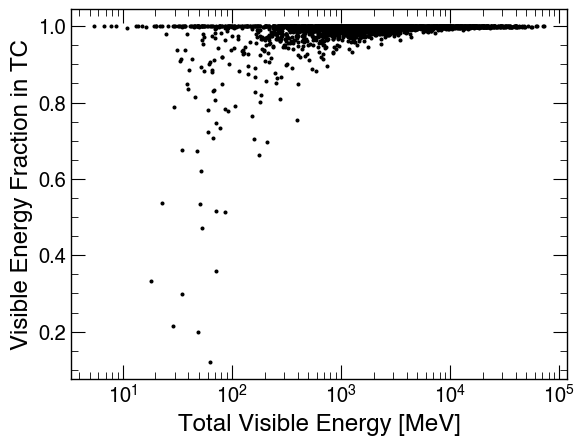

In [278]:
plt.scatter(df.total_visible_energy/1e4, df.ratio,s=2)
#plt.xscale('log')
plt.xlabel("Total Visible Energy [GeV]")
plt.ylabel("Visible Energy Fraction in TC")
plt.show()

plt.scatter(df.total_visible_energy, df.ratio,s=2)
plt.xscale('log')
plt.xlabel("Total Visible Energy [MeV]")
plt.ylabel("Visible Energy Fraction in TC")

In [266]:
df[(df.ccnc==0) & (df.ratio<0.5)] #which cc events supposedly were not triggered or had a poor completeness 

,event,matched_energy,total_visible_energy,ccnc,x,y,z,ratio,in_fv
953,78136,25.296164,53.661758,0,-24.281642,-228.748278,1414.335396,0.471400,False
970,78263,7.556100,63.008282,0,379.600854,465.283589,1115.595182,0.119922,False


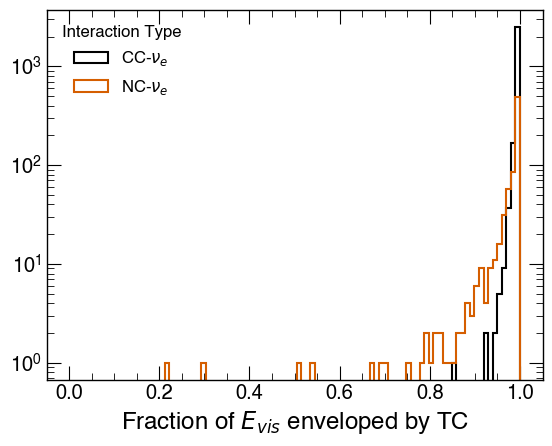

In [267]:
bins = np.linspace(0,1,100)
plt.hist(df[(df.ccnc==0) &(df.in_fv == True)].ratio, bins =bins, histtype='step', label = r'CC-$\nu_e$')
plt.hist(df[(df.ccnc==1) &(df.in_fv == True)].ratio, bins =bins, histtype='step', label = r'NC-$\nu_e$')
plt.legend(title='Interaction Type', title_fontsize=12)
plt.yscale('log')
plt.xlabel(r"Fraction of $E_{vis}$ enveloped by TC")
plt.show()

In [279]:
levels = [0.9, 0.99, 0.999] 
for i in levels:
    print(i,":", np.sum(df[(df.ccnc==0) &(df.in_fv == True)].ratio>i)/len(df[(df.ccnc==0) &(df.in_fv == True)]))
print('\n')
for i in levels:
    print(i,":", np.sum(df[(df.ccnc==1) &(df.in_fv == True)].ratio>i)/len(df[(df.ccnc==1) &(df.in_fv == True)]))

0.9 : 0.999634636463281
0.99 : 0.917427840701498
0.999 : 0.48374132261600294


0.9 : 0.9144316730523627
0.99 : 0.6245210727969349
0.999 : 0.3524904214559387


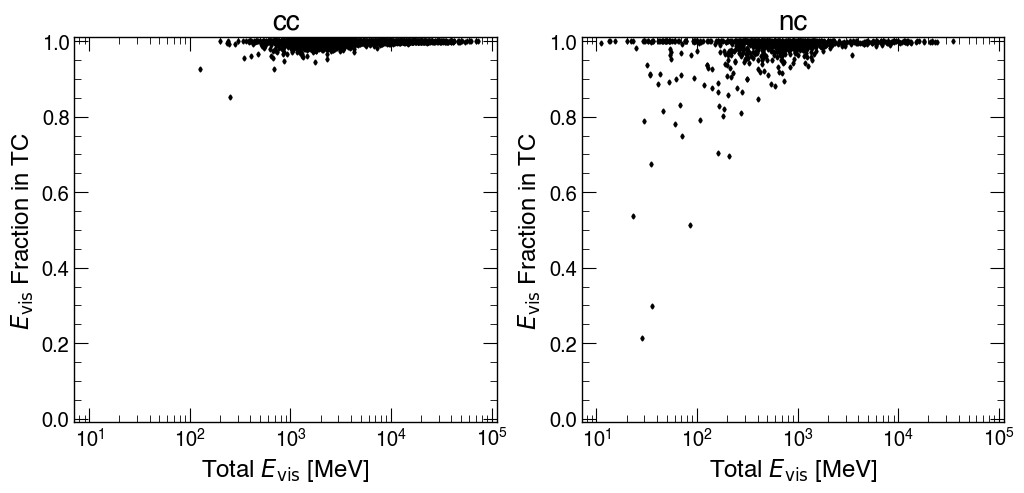

In [277]:
fig,ax = plt.subplots(1,2,figsize=(12,5),  sharex=True)
for idx , type_label in enumerate(ccnc_map):
    
    ax[idx].scatter(df[(df.in_fv==True) & (df.ccnc == idx)].total_visible_energy, df[(df.in_fv==True) & (df.ccnc == idx)].ratio, s=4, marker='d')
    ax[idx].set_xscale('log')
    ax[idx].set_xlabel(r"Total $E_{\mathrm{vis}}$ [MeV]")
    ax[idx].set_ylabel(r"$E_{\mathrm{vis}}$ Fraction in TC")
    ax[idx].set_ylim(-0.01,1.01)
    ax[idx].set_title(f'{type_label}', fontsize=20)
plt.show()

In [281]:
df[(df.ccnc==0) & (df.ratio<0.85)] #which cc events supposedly were not triggered or had a poor completeness 

,event,matched_energy,total_visible_energy,ccnc,x,y,z,ratio,in_fv
123,73814,118.133530,154.717453,0,30.386333,618.303355,574.149470,0.763544,False
227,74678,47.493484,67.183472,0,370.969885,-23.829690,236.198416,0.706922,False
484,75807,32.336681,51.991333,0,-213.828226,-380.527157,1417.526953,0.621963,False
529,76092,43.743942,60.569687,0,370.490898,-270.292963,147.778563,0.722208,False
953,78136,25.296164,53.661758,0,-24.281642,-228.748278,1414.335396,0.471400,False
970,78263,7.556100,63.008282,0,379.600854,465.283589,1115.595182,0.119922,False
1303,80377,37.236053,72.346985,0,-379.929276,-619.492920,1005.600010,0.514687,False
1546,82190,68.532104,80.797447,0,379.115601,443.914014,1196.538179,0.848196,False
1882,84468,295.384155,392.186676,0,379.639894,-106.648175,409.627347,0.753172,False
2073,85839,117.976227,177.882935,0,378.999638,12.284302,528.859229,0.663224,False
